In [18]:
from transformers import AutoFeatureExtractor, ViTForImageClassification
from PIL import Image
import torch
import numpy as np

# Load the feature extractor and model from Hugging Face
feature_extractor = AutoFeatureExtractor.from_pretrained("DunnBC22/vit-base-patch16-224-in21k-weather-images-classification")
model = ViTForImageClassification.from_pretrained("DunnBC22/vit-base-patch16-224-in21k-weather-images-classification")

# Load your satellite weather image (ensure it’s RGB)
image = Image.open("/kaggle/input/full-dataset-7000-rows/satellite_images/satellite_images/event0_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-10-28.png").convert("RGB")

image_np = np.array(image)
inputs = feature_extractor(images=image_np, return_tensors="pt")



In [20]:
model

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

In [19]:

# Option 1: Using the encoder (ViT model) directly
with torch.no_grad():
    # Pass the pixel_values to the internal ViT encoder
    outputs = model.vit(pixel_values=inputs["pixel_values"])
    # outputs.last_hidden_state shape: [batch_size, seq_length, hidden_size]
    cls_embedding = outputs.last_hidden_state[:, 0, :]  # Extract the [CLS] token embedding
    print("Feature vector shape:", cls_embedding.shape)

# Option 2: If you want to obtain all hidden states (for example, to experiment with different layers):
with torch.no_grad():
    outputs = model(pixel_values=inputs["pixel_values"], output_hidden_states=True)
    # The hidden states are returned as a tuple (one per layer)
    # Here, we extract the last layer's [CLS] token embedding:
    last_hidden_state = outputs.hidden_states[-1]  # Last encoder layer output
    cls_embedding = last_hidden_state[:, 0, :]
    print("Feature vector shape from last hidden state:", cls_embedding.shape)

Feature vector shape: torch.Size([1, 768])
Feature vector shape from last hidden state: torch.Size([1, 768])


In [15]:
model

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

In [21]:
import pandas as pd


df = pd.read_csv("/kaggle/input/full-dataset-7000-rows/merged_df_copy.csv")


<ipython-input-21-d38b52f0b722>:3: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/full-dataset-7000-rows/merged_df_copy.csv")


In [34]:
import ast
df = df.iloc[:7000,:]
df["filenames"] = df["filenames"].apply(lambda x: ast.literal_eval(x))

In [35]:
df["filenames"] = df["filenames"].apply(lambda x: [i for i in x if "MODIS_Terra_CorrectedReflectance_TrueColor" in i ])

In [36]:
df["filenames"].iloc[0]

['event0_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-10-29.png',
 'event0_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-10-28.png',
 'event0_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-10-27.png']

In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model.to(device)


In [42]:
device

device(type='cuda')

In [48]:
import numpy as np
import torch
from transformers import ViTFeatureExtractor, ViTModel
from PIL import Image
import tensorflow as tf
model_name='DunnBC22/vit-base-patch16-224-in21k-weather-images-classification'
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)
model = ViTModel.from_pretrained(model_name)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()  # Set the model to evaluation mode
def extract_features(filenames):
    # Initialize the feature extractor and model
    


    # List to hold feature vectors for each image
    features = []

    for filename in filenames:
        # Load and preprocess the image
        image = Image.open("/kaggle/input/full-dataset-7000-rows/satellite_images/satellite_images/"+filename).convert('RGB')
        inputs = feature_extractor(images=image, return_tensors="pt")
         # Move input data to the same device as the model
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            # Extract the [CLS] token embedding
            cls_embedding = outputs.last_hidden_state[:, 0, :]
            features.append(cls_embedding)

    # Concatenate all features into a single vector
    concatenated_features = torch.cat(features, dim=1)

    return tf.convert_to_tensor(concatenated_features.cpu().numpy())


/usr/local/lib/python3.10/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at DunnBC22/vit-base-patch16-224-in21k-weather-images-classification and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [49]:
from tqdm import tqdm
tqdm.pandas()
df["features"] = df["filenames"].progress_apply(extract_features)

100%|██████████| 7000/7000 [09:38<00:00, 12.11it/s]


In [64]:
df["features"].iloc[0].shape

TensorShape([1, 2304])

In [54]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# List of all weather feature columns (those starting with 'prev_')
weather_feature_columns = [col for col in df.columns if col.startswith('prev_') and col!="prev_72h_weather" and col!="prev_72h_snowfall" and col!="prev_72h_snow_depth" and col!="prev_72h_weather_code"]

# Create an empty 3D array with dimensions [n_samples, 72 timesteps, n_features]
n_samples = len(df)
n_timesteps = 72  # As each list contains 72 hours of data
n_features = len(weather_feature_columns)
time_series_data = np.zeros((n_samples, n_timesteps, n_features))

# Fill the array with values from each list
for i, feature_idx in enumerate(range(len(weather_feature_columns))):
    feature_col = weather_feature_columns[feature_idx]
    for sample_idx in range(n_samples):
        # Convert string representation of list to actual list if needed
        if isinstance(df.loc[sample_idx, feature_col], str):
            values = eval(df.loc[sample_idx, feature_col])
        else:
            values = df.loc[sample_idx, feature_col]
        
        # Make sure we have exactly 72 values
        if len(values) != n_timesteps:
            print(f"Warning: Sample {sample_idx}, feature {feature_col} has {len(values)} values instead of {n_timesteps}")
            # Pad or truncate if necessary
            values = values[:n_timesteps] + [0] * (n_timesteps - len(values))
        
        # Store the values in our 3D array
        time_series_data[sample_idx, :, feature_idx] = values

# Standardize the data
# Reshape to 2D for standardization
original_shape = time_series_data.shape
reshaped_data = time_series_data.reshape(-1, n_features)

# Apply standardization
scaler = StandardScaler()
standardized_reshaped_data = scaler.fit_transform(reshaped_data)

# Reshape back to 3D
standardized_time_series_data = standardized_reshaped_data.reshape(original_shape)

print(f"Final dataset shape: {standardized_time_series_data.shape}")

# Now you can use standardized_time_series_data with your model

Final dataset shape: (7000, 72, 27)


In [56]:
standardized_time_series_data.shape

(7000, 72, 27)

In [65]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Step 1: Extract image embeddings from the df['features'] column
def extract_tensor_value(tensor_str):
    """Extract numerical values from tensor string representation"""
    try:
        # This is a simplified approach - adjust based on your actual tensor string format
        tensor_value = eval(tensor_str)
        if isinstance(tensor_value, tf.Tensor):
            return tensor_value.numpy().flatten()
        return np.array(tensor_value).flatten()
    except:
        # Return zeros if extraction fails
        return np.zeros(2304)

# Create numpy array for image embeddings
image_embeddings = np.zeros((len(df), 2304))

# Extract image features from the dataframe
for i in range(len(df)):
    try:
        # Convert each tensor in features column to numpy array
        tensor_data = df.loc[i, 'features']
        if isinstance(tensor_data, tf.Tensor):
            image_embeddings[i] = tensor_data.numpy().reshape(-1)
        else:
            # If it's a string representation, extract the values
            image_embeddings[i] = extract_tensor_value(tensor_data)
    except Exception as e:
        print(f"Error processing row {i}: {e}")
        # Fill with zeros if extraction fails
        image_embeddings[i] = np.zeros(2304)

print(f"Image embeddings shape: {image_embeddings.shape}")

# Step 2: Define the multimodal model architecture
def build_multimodal_model(time_series_shape, image_embedding_shape, l2_reg=0.01):
    # Time series branch (weather data)
    time_series_input = layers.Input(shape=time_series_shape, name='time_series_input')
    
    # Normalize time series input
    x_ts = layers.BatchNormalization()(time_series_input)
    
    # LSTM layers for temporal features
    x_ts = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x_ts)
    x_ts = layers.Dropout(0.3)(x_ts)
    x_ts = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x_ts)
    
    # Self-attention mechanism
    attention = layers.Dense(1)(x_ts)
    attention = layers.Reshape((-1,))(attention)
    attention = layers.Activation('softmax')(attention)
    attention = layers.Reshape((-1, 1))(attention)
    
    # Apply attention to the sequence
    x_ts = layers.Multiply()([x_ts, attention])
    x_ts = layers.GlobalAveragePooling1D()(x_ts)
    
    # Image embedding branch
    image_input = layers.Input(shape=image_embedding_shape, name='image_input')
    
    # Process image embeddings
    x_img = layers.BatchNormalization()(image_input)
    x_img = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x_img)
    x_img = layers.Dropout(0.3)(x_img)
    x_img = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x_img)
    x_img = layers.BatchNormalization()(x_img)
    
    # Combine both modalities
    combined = layers.Concatenate()([x_ts, x_img])
    
    # Joint processing layers
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # Output layer
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    # Create model with two inputs
    model = models.Model(inputs=[time_series_input, image_input], outputs=outputs)
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall(),
            tf.keras.metrics.AUC(),
            tf.keras.metrics.AUC(curve='PR', name='prc')
        ]
    )
    
    return model


Image embeddings shape: (7000, 2304)


In [73]:
image_embeddings.shape, standardized_time_series_data.shape, df["extreme"].shape

((7000, 2304), (7000, 72, 27), (7000,))

In [85]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import numpy as np
import tensorflow as tf
from sklearn.utils import class_weight
# Assuming your data is already loaded as follows:
# image_embeddings: Shape (7000, 2304)
# time_series_data: Shape (7000, 72, 27)
# labels: Shape (7000,)
labels = df["extreme"].values
# Set up Stratified K-Fold cross-validation
n_splits = 2  # Number of folds
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize lists to store metrics for averaging
accuracies = []
precisions = []
recalls = []
aucs = []
prcs = []

# Loop through each split in Stratified K-Fold
for fold, (train_idx, val_idx) in enumerate(skf.split(image_embeddings, labels), 1):
    print(f"Training fold {fold}/{n_splits}...")
    
    # Split data for training and validation based on the indices from StratifiedKFold
    X_train_img = image_embeddings[train_idx]
    X_val_img = image_embeddings[val_idx]

    X_train_ts = time_series_data[train_idx]
    X_val_ts = time_series_data[val_idx]
    
    y_train = labels[train_idx]
    y_val = labels[val_idx]
    class_weights = class_weight.compute_class_weight(
        'balanced', classes=np.unique(y_train), y=y_train
    )
    class_weights_dict = {0: class_weights[0], 1: class_weights[1]}
    # Train the model
    model = build_multimodal_model(time_series_shape=(X_train_ts.shape[1], X_train_ts.shape[2]),  image_embedding_shape=X_train_img.shape[1:])
    
    # Train the model with training data and validate on validation data
    model.fit([X_train_ts, X_train_img], y_train, 
              validation_data=([X_val_ts, X_val_img], y_val), 
              epochs=10, batch_size=32, verbose=1,class_weight=class_weights_dict)
    
    # Predict on validation data
    y_pred = (model.predict([X_val_ts, X_val_img]) > 0.5).astype(int)
    
    # Calculate metrics for this fold
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred)
    prc = average_precision_score(y_val, y_pred)
    
    # Store metrics for averaging
    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    aucs.append(auc)
    prcs.append(prc)
    
    # Print metrics for this fold
    print(f"Fold {fold} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, AUC: {auc:.4f}, PRC: {prc:.4f}")
    
# Calculate and print average metrics across all folds
print("\nAverage metrics across all folds:")
print(f"Average Accuracy: {np.mean(accuracies):.4f}")
print(f"Average Precision: {np.mean(precisions):.4f}")
print(f"Average Recall: {np.mean(recalls):.4f}")
print(f"Average AUC: {np.mean(aucs):.4f}")
print(f"Average PRC: {np.mean(prcs):.4f}")


Training fold 1/2...
Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - auc_5: 0.4932 - binary_accuracy: 0.4840 - loss: 9.3344 - prc: 0.0671 - precision_5: 0.0692 - recall_5: 0.5480 - val_auc_5: 0.5542 - val_binary_accuracy: 0.2260 - val_loss: 7.6768 - val_prc: 0.0759 - val_precision_5: 0.0672 - val_recall_5: 0.8694
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - auc_5: 0.6001 - binary_accuracy: 0.5243 - loss: 7.2204 - prc: 0.0863 - precision_5: 0.0720 - recall_5: 0.6329 - val_auc_5: 0.5995 - val_binary_accuracy: 0.7440 - val_loss: 5.9625 - val_prc: 0.1228 - val_precision_5: 0.0969 - val_recall_5: 0.3649
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - auc_5: 0.6300 - binary_accuracy: 0.5560 - loss: 5.8265 - prc: 0.1158 - precision_5: 0.0941 - recall_5: 0.5936 - val_auc_5: 0.6206 - val_binary_accuracy: 0.7009 - val_loss: 4.7543 - val_prc: 0.1240 - val_precision_5: 0.0983 - val_recall_5: 0.4550
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - auc_5: 0.6454 - bina

NameError: name 'average_precision_score' is not defined

In [68]:

# Step 5: Build and train the model
model = build_multimodal_model(
    time_series_shape=(standardized_time_series_data.shape[1], standardized_time_series_data.shape[2]),
    image_embedding_shape=(image_embeddings.shape[1],)
)

# Define callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_prc',
        patience=10,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001
    )
]

# Train the model
history = model.fit(
    [X_train_ts, X_train_img],
    y_train,
    validation_data=([X_val_ts, X_val_img], y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=callbacks
)


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 4200, 0
'y' sizes: 4200
'sample_weight' sizes: 4200


In [ ]:

# Step 6: Evaluate on test set
test_results = model.evaluate([X_test_ts, X_test_img], y_test)
print(f"Test results: {dict(zip(model.metrics_names, test_results))}")

# Step 7: Plot training history
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(history.history['auc'], label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(history.history['prc'], label='Training PR AUC')
plt.plot(history.history['val_prc'], label='Validation PR AUC')
plt.title('PR AUC')
plt.legend()

plt.tight_layout()
plt.show()

# Step 8: Generate predictions on test set
y_pred_prob = model.predict([X_test_ts, X_test_img])
y_pred = (y_pred_prob > 0.5).astype(int)

# Step 9: Calculate and display confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

## old

In [ ]:
import os
import ast
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from PIL import Image
                      
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Define constants
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 30
NUM_TIME_STEPS = 72  # 72 hours of meteorological data
TIME_SERIES_FEATURES = 27  # Number of meteorological features
IMAGE_LAYERS = 3  # Number of different satellite imagery types per day
DAYS = 3  # 3 days of satellite imagery

In [12]:
from tqdm import tqdm
tqdm.pandas()
def conver_to_float(s):
    try:
        return [float(i) for i in ast.literal_eval(s)]
    except Exception as e:
        print(e)

        return None
# Function to load and preprocess the dataset
def load_data(data_path='/kaggle/input/capstone-project-ds/merged_df_copy_kaggle.csv', image_dir=r'/kaggle/input/capstone-project-ds/kaggle_satellite_images/'):
    # Load the dataframe
    df = pd.read_csv(data_path)
    
    # Keep only rows that have satellite image data
    df = df.dropna(subset=['filenames'])
    
    prev_cols = [col for col in df.columns if 'prev_72h' in col]
    prev_cols.remove('prev_72h_weather')
    prev_cols.remove("prev_72h_snowfall")
    prev_cols.remove("prev_72h_snow_depth")
    print(prev_cols)
    for col in prev_cols:
        df[col] = df[col].progress_apply(conver_to_float)

    
    df['filenames'] = df['filenames'].apply(ast.literal_eval)
    df.drop(columns=["prev_72h_weather", "prev_72h_snowfall", "prev_72h_snow_depth"], inplace=True)
    extreme = df[df['extreme'] == 1]
    non_extreme = df[df['extreme'] == 0].sample(n=extreme.shape[0], random_state=42)
    df = pd.concat([extreme, non_extreme], ignore_index=True)
    return df, image_dir

In [13]:
# Function to preprocess meteorological time series data
def preprocess_meteo_data(df):
    # Select only the meteorological columns that contain numerical data
    meteo_cols = [col for col in df.columns if col.startswith('prev_72h_') 
                  and col != 'prev_72h_weather' and col != 'prev_72h_weather_code']

    # Create a numpy array to hold the time series data
    X_meteo = np.zeros((len(df), NUM_TIME_STEPS, len(meteo_cols)))
    
    # Fill the array with the time series data
    for i, row in df.iterrows():
        for j, col in enumerate(meteo_cols):
            try:
                # Handle potential issues with the data
                values = row[col]
                if len(values) < NUM_TIME_STEPS:
                    # Pad with zeros if we have fewer than 72 time steps
                    values = values + [0] * (NUM_TIME_STEPS - len(values))
                elif len(values) > NUM_TIME_STEPS:
                    # Truncate if we have more than 72 time steps
                    values = values[:NUM_TIME_STEPS]
                X_meteo[i, :, j] = values
            except Exception as e:
                print(f"Error processing {col} for row {i}: {e}")
                X_meteo[i, :, j] = np.zeros(NUM_TIME_STEPS)
    
    # Normalize the data
    # Reshape to 2D for scaling
    original_shape = X_meteo.shape
    X_meteo_2d = X_meteo.reshape(-1, X_meteo.shape[-1])
    
    scaler = StandardScaler()
    X_meteo_2d = scaler.fit_transform(X_meteo_2d)
    
    # Reshape back to 3D
    X_meteo = X_meteo_2d.reshape(original_shape)
    
    return X_meteo, meteo_cols

In [14]:
def create_tf_dataset(df, image_dir, batch_size=BATCH_SIZE):
    """
    Creates a TensorFlow dataset for training and validation using actual data
    """
    def generator():
        for _, row in df.iterrows():
            # Initialize arrays for this sample
            meteo_cols = [col for col in df.columns 
                         if col.startswith('prev_72h_') 
                         and col != 'prev_72h_weather'
                         and col != 'prev_72h_weather_code']
            
            meteo_data = np.zeros((NUM_TIME_STEPS, len(meteo_cols)))
            image_data = np.zeros((DAYS, IMAGE_LAYERS, *IMAGE_SIZE, 3))
            label = row['extreme']
            
            # Fill the meteo_data array with actual data
            for j, col in enumerate(meteo_cols):
                try:
                    # Extract values from the row
                    values = row[col]
                    if isinstance(values, str):
                        values = ast.literal_eval(values)
                    
                    # Handle lists of different lengths
                    if len(values) > NUM_TIME_STEPS:
                        values = values[:NUM_TIME_STEPS]
                    elif len(values) < NUM_TIME_STEPS:
                        values = values + [0] * (NUM_TIME_STEPS - len(values))
                        
                    meteo_data[:, j] = values
                except Exception as e:
                    print(f"Error processing {col}: {e}")
            
            # Load images for this event - FIX THE FILENAMES CHECK
            filenames = None
            try:
                # Check if filenames exist as a string that needs to be evaluated
                if isinstance(row['filenames'], str):
                    try:
                        filenames = ast.literal_eval(row['filenames'])
                    except:
                        print(f"Could not parse filenames for row")
                # Or if it's already a list
                elif isinstance(row['filenames'], list):
                    filenames = row['filenames']
                # Or if it's a numpy array or pandas Series
                elif isinstance(row['filenames'], (np.ndarray, pd.Series)):
                    if len(row['filenames']) > 0:
                        # Convert first element to string if it's not already
                        if not isinstance(row['filenames'][0], str):
                            try:
                                filenames = [str(f) for f in row['filenames']]
                            except:
                                print(f"Could not convert filenames to strings")
                        else:
                            filenames = list(row['filenames'])
            except Exception as e:
                print(f"Error processing filenames: {e}")
            
            # Process filenames if they exist
            if filenames:
                # Group filenames by date
                grouped_files = {}
                for filename in filenames:
                    try:
                        date = filename.split('_')[-1].replace('.png', '')
                        if date not in grouped_files:
                            grouped_files[date] = []
                        grouped_files[date].append(filename)
                    except Exception as e:
                        print(f"Error grouping filename {filename}: {e}")
                
                # Sort dates and take the last 3 days
                sorted_dates = sorted(grouped_files.keys())
                if len(sorted_dates) > DAYS:
                    sorted_dates = sorted_dates[-DAYS:]
                
                # For each of the last 3 days
                for day_idx, date in enumerate(sorted_dates):
                    if day_idx >= DAYS:
                        break
                        
                    # For each image layer type
                    day_files = sorted(grouped_files[date])
                    for img_idx, img_file in enumerate(day_files[:IMAGE_LAYERS]):
                        if img_idx >= IMAGE_LAYERS:
                            break
                            
                        try:
                            img_path = os.path.join(image_dir, img_file)
                            if os.path.exists(img_path):
                                img = Image.open(img_path).resize(IMAGE_SIZE)
                                img_array = np.array(img) / 255.0  # Normalize
                                
                                # Handle grayscale images
                                if len(img_array.shape) == 2:
                                    img_array = np.stack([img_array, img_array, img_array], axis=-1)
                                elif img_array.shape[2] == 4:  # Handle RGBA
                                    img_array = img_array[:, :, :3]
                                    
                                image_data[day_idx, img_idx] = img_array
                        except Exception as e:
                            print(f"Error loading image {img_file}: {e}")
            
            yield (meteo_data, image_data), label
    
    # Define the output types and shapes for the dataset
    meteo_cols = [col for col in df.columns 
                 if col.startswith('prev_72h_') 
                 and col != 'prev_72h_weather'
                 and col != 'prev_72h_weather_code']
    
    output_types = (
        (tf.float32, tf.float32),  # (meteo_data, image_data)
        tf.int32                    # label
    )
    
    output_shapes = (
        (
            (NUM_TIME_STEPS, len(meteo_cols)),  # meteo_data shape with actual column count
            (DAYS, IMAGE_LAYERS, *IMAGE_SIZE, 3) # image_data shape
        ),
        ()                                      # label shape (scalar)
    )
    
    # Create and configure the dataset
    dataset = tf.data.Dataset.from_generator(
        generator,
        output_types=output_types,
        output_shapes=output_shapes
    )
    
    # Batch and prefetch for performance
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    dataset = dataset.repeat()
    
    return dataset

In [15]:
# Fix for the build_transformer_model function

def build_transformer_model(input_shape):
    inputs = Input(shape=input_shape)
    
    # Create a custom positional encoding layer
    class PositionalEncoding(layers.Layer):
        def __init__(self, position, d_model):
            super().__init__()
            self.pos_encoding = self.positional_encoding(position, d_model)
        
        def get_angles(self, pos, i, d_model):
            angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
            return pos * angle_rates
        
        def positional_encoding(self, position, d_model):
            angle_rads = self.get_angles(
                np.arange(position)[:, np.newaxis],
                np.arange(d_model)[np.newaxis, :],
                d_model
            )
            
            # Apply sin to even indices in the array
            sines = np.sin(angle_rads[:, 0::2])
            # Apply cos to odd indices in the array
            cosines = np.cos(angle_rads[:, 1::2])
            
            pos_encoding = np.zeros(angle_rads.shape)
            pos_encoding[:, 0::2] = sines
            pos_encoding[:, 1::2] = cosines
            
            pos_encoding = tf.cast(pos_encoding[np.newaxis, ...], tf.float32)
            
            return pos_encoding
        
        def call(self, inputs):
            return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]
    
    # Project input to match embedding dimension
    x = layers.Dense(64)(inputs)
    # Fix for the build_transformer_model function

def build_transformer_model(input_shape):
    inputs = Input(shape=input_shape)
    
    # Create a custom positional encoding layer
    class PositionalEncoding(layers.Layer):
        def __init__(self, position, d_model):
            super().__init__()
            self.pos_encoding = self.positional_encoding(position, d_model)
        
        def get_angles(self, pos, i, d_model):
            angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
            return pos * angle_rates
        
        def positional_encoding(self, position, d_model):
            angle_rads = self.get_angles(
                np.arange(position)[:, np.newaxis],
                np.arange(d_model)[np.newaxis, :],
                d_model
            )
            
            # Apply sin to even indices in the array
            sines = np.sin(angle_rads[:, 0::2])
            # Apply cos to odd indices in the array
            cosines = np.cos(angle_rads[:, 1::2])
            
            pos_encoding = np.zeros(angle_rads.shape)
            pos_encoding[:, 0::2] = sines
            pos_encoding[:, 1::2] = cosines
            
            pos_encoding = tf.cast(pos_encoding[np.newaxis, ...], tf.float32)
            
            return pos_encoding
        
        def call(self, inputs):
            return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]
    
    # Project input to match embedding dimension
    x = layers.Dense(64)(inputs)
    
    # Add positional encoding
    x = PositionalEncoding(input_shape[0], 64)(x)
    
    # Multi-head attention
    attention_output = layers.MultiHeadAttention(
        num_heads=4, key_dim=16
    )(x, x, x)
    
    # Add & Normalize
    attention_output = layers.LayerNormalization(epsilon=1e-6)(x + attention_output)
    
    # Feed-forward network
    ffn = layers.Dense(128, activation='relu')(attention_output)
    ffn = layers.Dropout(0.1)(ffn)
    ffn = layers.Dense(64)(ffn)
    
    # Add & Normalize
    transformer_output = layers.LayerNormalization(epsilon=1e-6)(attention_output + ffn)
    
    # Global average pooling to reduce sequence dimension
    transformer_output = layers.GlobalAveragePooling1D()(transformer_output)
    
    return inputs, transformer_output
    # Add positional encoding
    x = PositionalEncoding(input_shape[0], 64)(x)
    
    # Multi-head attention
    attention_output = layers.MultiHeadAttention(
        num_heads=4, key_dim=16
    )(x, x, x)
    
    # Add & Normalize
    attention_output = layers.LayerNormalization(epsilon=1e-6)(x + attention_output)
    
    # Feed-forward network
    ffn = layers.Dense(128, activation='relu')(attention_output)
    ffn = layers.Dropout(0.1)(ffn)
    ffn = layers.Dense(64)(ffn)
    
    # Add & Normalize
    transformer_output = layers.LayerNormalization(epsilon=1e-6)(attention_output + ffn)
    
    # Global average pooling to reduce sequence dimension
    transformer_output = layers.GlobalAveragePooling1D()(transformer_output)
    
    return inputs, transformer_output

In [16]:
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)
    
    # Custom layer to handle reshaping
    class ReshapeLayer(layers.Layer):
        def __init__(self, target_shape=None):
            super().__init__()
            self.target_shape = target_shape
        
        def call(self, inputs):
            batch_size = tf.shape(inputs)[0]
            flattened = tf.reshape(inputs, [-1, *self.target_shape])
            return flattened, batch_size
    
    class ReshapeBackLayer(layers.Layer):
        def __init__(self, days, layers, feature_dim):
            super().__init__()
            self.days = days
            self.layers = layers
            self.feature_dim = feature_dim
        
        def call(self, inputs, batch_size):
            return tf.reshape(inputs, [batch_size, self.days, self.layers, self.feature_dim])
    
    target_shape = input_shape[-3:]
    reshaped_inputs, batch_size = ReshapeLayer(target_shape=target_shape)(inputs)
    
    # Simplified CNN layers
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(reshaped_inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)  # Lower dropout for simplicity
    
    feature_dim = 128
    x = ReshapeBackLayer(DAYS, IMAGE_LAYERS, feature_dim)(x, batch_size)

    class ReduceMeanLayer(layers.Layer):
        def call(self, inputs):
            return tf.reduce_mean(inputs, axis=2)
    
    x = ReduceMeanLayer()(x)

    x = layers.TimeDistributed(layers.Dense(64, activation='relu'))(x)
    x = layers.GlobalAveragePooling1D()(x) 

    return inputs, x

In [17]:
# Combined model
def build_combined_model(meteo_shape, image_shape):
    # Meteorological time series branch
    meteo_input, meteo_features = build_transformer_model(meteo_shape)
    
    # Satellite imagery branch
    image_input, image_features = build_cnn_model(image_shape)
    
    # Combine features from both branches
    combined = layers.Concatenate()([meteo_features, image_features])
    
    # Final classification layers
    x = layers.Dense(128, activation='relu')(combined)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    # Create the combined model
    model = Model([meteo_input, image_input], output)
    
    # Compile the model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    
    return model


In [18]:
# Main function to train the model
def train_extreme_weather_model():
    # Load the dataset
    df, image_dir = load_data()
    print(f"Loaded dataset with {len(df)} rows")
    
    # Preprocess meteorological data
    X_meteo, meteo_cols = preprocess_meteo_data(df)
    print(f"Processed meteorological data with shape {X_meteo.shape}")
    
    # Split the data
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['extreme'])
    
    # Create data generators
    train_gen = create_tf_dataset(train_df, image_dir)
    val_gen = create_tf_dataset(val_df, image_dir)
    
    # Build the model
    meteo_shape = (NUM_TIME_STEPS, len(meteo_cols))
    image_shape = (DAYS, IMAGE_LAYERS, *IMAGE_SIZE, 3)
    model = build_combined_model(meteo_shape, image_shape)
    
    # Define callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        # ModelCheckpoint('extreme_weather_model.h5', save_best_only=True),
        ReduceLROnPlateau(factor=0.2, patience=3)
    ]
    
    history = model.fit(
        train_gen,
        steps_per_epoch=len(train_df) // BATCH_SIZE,
        validation_data=val_gen,
        validation_steps=len(val_df) // BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=callbacks
    )
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.close()
    
    return model, history

In [19]:
model, history = train_extreme_weather_model()

['prev_72h_temperature_2m', 'prev_72h_relative_humidity_2m', 'prev_72h_dew_point_2m', 'prev_72h_apparent_temperature', 'prev_72h_precipitation', 'prev_72h_rain', 'prev_72h_weather_code', 'prev_72h_pressure_msl', 'prev_72h_surface_pressure', 'prev_72h_cloud_cover', 'prev_72h_cloud_cover_low', 'prev_72h_cloud_cover_mid', 'prev_72h_cloud_cover_high', 'prev_72h_et0_fao_evapotranspiration', 'prev_72h_vapour_pressure_deficit', 'prev_72h_wind_speed_10m', 'prev_72h_wind_speed_100m', 'prev_72h_wind_direction_10m', 'prev_72h_wind_direction_100m', 'prev_72h_wind_gusts_10m', 'prev_72h_soil_temperature_0_to_7cm', 'prev_72h_soil_temperature_7_to_28cm', 'prev_72h_soil_temperature_28_to_100cm', 'prev_72h_soil_temperature_100_to_255cm', 'prev_72h_soil_moisture_0_to_7cm', 'prev_72h_soil_moisture_7_to_28cm', 'prev_72h_soil_moisture_28_to_100cm', 'prev_72h_soil_moisture_100_to_255cm']


100%|██████████| 888/888 [00:00<00:00, 6176.60it/s]


Loaded dataset with 888 rows
Processed meteorological data with shape (888, 72, 27)
Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 454ms/step - accuracy: 0.4986 - auc_1: 0.4663 - loss: 0.8045 - precision_1: 0.4586 - recall_1: 0.3326 - val_accuracy: 0.5063 - val_auc_1: 0.4966 - val_loss: 0.6944 - val_precision_1: 0.5063 - val_recall_1: 1.0000 - learning_rate: 0.0010
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - accuracy: 0.5183 - auc_1: 0.4870 - loss: 0.7116 - precision_1: 0.5075 - recall_1: 0.6001 - val_accuracy: 0.4863 - val_auc_1: 0.5165 - val_loss: 0.6932 - val_precision_1: 0.4889 - val_recall_1: 0.9167 - learning_rate: 0.0010
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.4880 - auc_1: 0.4811 - loss: 0.7141 - precision_1: 0.5086 - recall_1: 0.4958 - val_accuracy: 0.4726 - val_auc_1: 0.4833 - val_loss: 0.6983 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.5191 - 

In [106]:
model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_47            │ (None, 3, 3, 128, 128, │              0 │ -                      │
│ (InputLayer)              │ 3)                     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_layer_19          │ [(None, 128, 128, 3),  │              0 │ input_layer_47[0][0]   │
│ (ReshapeLayer)            │ ()]                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_102 (Conv2D)       │ (None, 128, 128, 32)   │            896 │ reshape_layer_19[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_46            │ (None, 72, 27)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_76          │ (None, 64, 64, 32)     │              0 │ conv2d_102[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_169 (Dense)         │ (None, 72, 64)         │          1,792 │ input_layer_46[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_103 (Conv2D)       │ (None, 64, 64, 64)     │         18,496 │ max_pooling2d_76[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ positional_encoding_23    │ (None, 72, 64)         │              0 │ dense_169[0][0]        │
│ (PositionalEncoding)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_77          │ (None, 32, 32, 64)     │              0 │ conv2d_103[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_23   │ (None, 72, 64)         │         16,640 │ positional_encoding_2… │
│ (MultiHeadAttention)      │                        │                │ positional_encoding_2… │
│                           │                        │                │ positional_encoding_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_104 (Conv2D)       │ (None, 32, 32, 128)    │         73,856 │ max_pooling2d_77[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_46 (Add)              │ (None, 72, 64)         │              0 │ positional_encoding_2… │
│                           │                        │                │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_78          │ (None, 16, 16, 128)    │              0 │ conv2d_104[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_46    │ (None, 72, 64)         │            128 │ add_46[0][0]           │
│ (LayerNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 534,341 (2.04 MB)

 Trainable params: 178,113 (695.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 356,228 (1.36 MB)

In [1]:
%pip install satlaspretrain_models

Note: you may need to restart the kernel to use updated packages.


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
device = xm.xla_device()

In [16]:
# Add at the beginning of your script
import torch_xla.utils.utils as xu

# Replace your torch.backends settings with:
xu.set_optimization_level(3)  # TPU-specific optimization


AttributeError: module 'torch_xla.utils.utils' has no attribute 'set_optimization_level'

In [16]:
import satlaspretrain_models
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
weights_manager = satlaspretrain_models.Weights()
model = weights_manager.get_pretrained_model(model_identifier="Sentinel2_SwinB_SI_RGB", device=device)
model = model.to(device)


# Load the model weights onto the CPU

model.eval()

Using device: cuda


/usr/local/lib/python3.10/dist-packages/satlaspretrain_models/model.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(weights_file)


Model(
  (backbone): SwinBackbone(
    (backbone): SwinTransformer(
      (features): Sequential(
        (0): Sequential(
          (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        )
        (1): Sequential(
          (0): SwinTransformerBlockV2(
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (attn): ShiftedWindowAttentionV2(
              (qkv): Linear(in_features=128, out_features=384, bias=True)
              (proj): Linear(in_features=128, out_features=128, bias=True)
              (cpb_mlp): Sequential(
                (0): Linear(in_features=2, out_features=512, bias=True)
                (1): ReLU(inplace=True)
                (2): Linear(in_features=512, out_features=4, bias=False)
              )
            )
            (stochastic_depth): StochasticDepth(p=0.0, mode=row)
            (norm2): LayerNorm((128,), eps=1e-05, element

In [29]:
import torch
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
import ast
import logging
from tqdm.auto import tqdm
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

# ==========================
# SET UP LOGGING AND CUDA
# ==========================
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Enable CUDA optimizations for maximum performance
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
# ==========================
# LOAD DATAFRAME
# ==========================
df = pd.read_csv("/kaggle/input/full-dataset-7000-rows/merged_df_copy.csv")


def safe_literal_eval(x):
    """Safely evaluate a string representation of a list."""
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return []
df['filenames'] = df['filenames'].apply(safe_literal_eval)
# Set device


# Get CUDA info
if torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"Memory allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    print(f"Memory reserved: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")

# ==========================
# LOAD MODEL AND MOVE TO GPU EFFICIENTLY
# ==========================
# Make sure the model is on GPU and in eval mode for maximum speed
model = model.to(device)
model.eval()

# Create feature extraction hooks for efficiency
selected_layers = [2, 4, 6]  # Adjust these indices as needed
layer_features = {}

def get_activation_hook(name):
    """Create a hook function to capture outputs of specific layers"""
    def hook(module, input, output):
        # Average pooling on the output
        pooled = torch.mean(output, dim=(2, 3))
        layer_features[name] = pooled
    return hook

# Register hooks to capture features
hooks = []
for i, layer in enumerate(model.backbone.backbone.features):
    if i in selected_layers:
        hook = layer.register_forward_hook(get_activation_hook(f"layer_{i}"))
        hooks.append(hook)

# ==========================
# IMAGE PREPROCESSING OPTIMIZED
# ==========================
preprocess = transforms.Compose([
    transforms.Resize(256, antialias=True),  # Faster resize
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


<ipython-input-29-920d5fd438ad>:23: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/full-dataset-7000-rows/merged_df_copy.csv")


CUDA Device: Tesla T4
CUDA Memory: 15.83 GB
Memory allocated: 0.73 GB
Memory reserved: 0.89 GB


In [30]:
import pickle
# ==========================
# BATCH PROCESSING FOR MAXIMUM GPU UTILIZATION
# ==========================
def process_batch(batch_filenames, base_path="/kaggle/input/full-dataset-7000-rows/satellite_images/satellite_images"):
    """
    Process multiple rows of images in a single batch for maximum GPU utilization
    
    Args:
        batch_filenames: List of lists, where each inner list contains filenames for one row
        base_path: Base path to image directory
    
    Returns:
        List of feature arrays, one per row
    """
    batch_results = []
    
    # Process each row's filenames
    for row_filenames in batch_filenames:
        row_features = []
        
        # Process each image in the row
        for file in row_filenames:
            try:
                # Load and preprocess image
                img_path = os.path.join(base_path, file)
                image = Image.open(img_path).convert('RGB')
                image_tensor = preprocess(image).unsqueeze(0).to(device)
                
                # Clear previous features
                layer_features.clear()
                
                # Forward pass through the model
                with torch.no_grad():
                    _ = model(image_tensor)
                
                # Collect features from all selected layers
                feature_tensors = []
                for i in selected_layers:
                    key = f"layer_{i}"
                    if key in layer_features:
                        feature_tensors.append(layer_features[key])
                # print(feature_tensors)
                # Concatenate features from all layers
                if feature_tensors:
                    concat_features = torch.cat(feature_tensors, dim=1)
                    row_features.append(concat_features.cpu().numpy().squeeze())
                
            except Exception as e:
                logging.error(f"Error processing file {file}: {e}")
                # Add zeros as fallback
                if row_features:
                    feature_size = row_features[0].shape[0]
                else:
                    feature_size = 98  # Default
                row_features.append(np.zeros(feature_size))
        
        # Combine all features for this row
        if row_features:
            combined = np.concatenate(row_features)
        else:
            combined = np.zeros(98)
        
        batch_results.append(combined)
    
    return batch_results

# ==========================
# OPTIMIZED PROCESSING PIPELINE
# ==========================
def process_dataframe_in_batches(df, batch_size):
    """Process the dataframe in batches for maximum GPU utilization"""
    all_results = []
    rows = df['filenames'].tolist()
    
    # Process in batches
    for i in tqdm(range(0, len(rows), batch_size), desc="Processing batches"):
        # Get the current batch of rows
        batch = rows[i:i+batch_size]
        
        # Process this batch and get results
        batch_results = process_batch(batch)
        all_results.extend(batch_results)
        
        # # Periodically clear CUDA cache
        if i % 10 == 0:
            with open(f"batch_results_batach_{i}.pkl","wb") as f:
                pickle.dump(batch_results, f)
            
    return all_results

# ==========================
# IMAGE LOADING WITH PREFETCHING
# ==========================
def prefetch_images(filenames, base_path="/kaggle/input/full-dataset-7000-rows/satellite_images/satellite_images"):
    """Prefetch images in parallel to speed up loading"""
    def load_single(filename):
        try:
            img_path = os.path.join(base_path, filename)
            img = Image.open(img_path).convert('RGB')
            return filename, img
        except Exception as e:
            return filename, None
    
    # Use ThreadPoolExecutor for parallel loading
    with ThreadPoolExecutor(max_workers=4) as executor:
        futures = {executor.submit(load_single, f): f for f in filenames}
        images = {}
        for future in as_completed(futures):
            filename, img = future.result()
            if img is not None:
                images[filename] = img
    
    return images


In [ ]:

# ==========================
# MAIN EXECUTION
# ==========================
# Parse filenames from dataframe if needed
if 'filenames' in df.columns:
    df['filenames'] = df['filenames'].apply(lambda x: 
        ast.literal_eval(x) if isinstance(x, str) else x)

# Determine optimal batch size based on GPU memory
# For 10GB, a batch size of 16-32 is usually good
batch_size = 128  # Adjust based on your specific GPU and model

# Process dataframe in optimized batches
logging.info("Starting optimized batch processing with GPU acceleration")
results = process_dataframe_in_batches(df, batch_size)

# Add results to dataframe
df['image_features'] = results
logging.info(f"Completed feature extraction for {len(results)} rows")

# Clean up hooks
for hook in hooks:
    hook.remove()

# Save results
df.to_csv('df_with_features.csv', index=False)
logging.info("Results saved to CSV")

Processing batches:   0%|          | 0/275 [00:00<?, ?it/s]

In [25]:
df["image_features"].iloc[5].shape

(1176,)

In [27]:
import os
os.environ['XLA_USE_BF16'] = '1'  # Enable TPU-optimized format

import torch
import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.distributed.parallel_loader as pl
import satlaspretrain_models
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
import ast
import logging

# Initialize TPU first
device = xm.xla_device()
logging.basicConfig(level=logging.INFO)

# ======================
# MODEL INITIALIZATION
# ======================
def load_tpu_model():
    weights_manager = satlaspretrain_models.Weights()
    model = weights_manager.get_pretrained_model(
        "Sentinel2_SwinB_SI_RGB",
        device='cpu'  # Load on CPU first for compatibility
    )
    return model.to(device).eval()

model = load_tpu_model()

# ======================
# FEATURE EXTRACTION SETUP
# ======================
selected_layers = [2, 4, 6]
layer_features = {}
# Modify the feature extraction hook creation
def create_feature_hooks():
    def hook_fn(name):
        def hook(_, __, output):
            # First compute mean over spatial dimensions
            local_mean = torch.mean(output, dim=(2, 3))
            # Then reduce across TPU cores
            pooled = xm.mesh_reduce(f'pool_{name}', local_mean, lambda xs: torch.cat(xs, dim=0))
            layer_features[name] = pooled.detach()
        return hook
    
    hooks = []
    for i, layer in enumerate(model.backbone.backbone.features):
        if i in selected_layers:
            hook = layer.register_forward_hook(hook_fn(f'layer_{i}'))
            hooks.append(hook)
    return hooks
hooks = create_feature_hooks()

# ======================
# TPU-OPTIMIZED DATA PIPELINE
# ======================
class TPUImageDataset(torch.utils.data.Dataset):
    def __init__(self, filenames):
        self.filenames = filenames
        self.transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
        
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        try:
            path = f"/kaggle/input/full-dataset-7000-rows/satellite_images/satellite_images/{self.filenames[idx]}"
            return self.transform(Image.open(path).convert('RGB'))
        except:
            return torch.zeros(3, 224, 224)  # TPU-compatible fallback

# Add tqdm import at the top
from tqdm.auto import tqdm



# Update the processing loop with progress bar
def process_dataframe(df, batch_size=128):
    all_files = df['filenames'].explode().tolist()
    dataset = TPUImageDataset(all_files)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=4
    )
    
    para_loader = pl.ParallelLoader(dataloader, [device]).per_device_loader(device)
    
    features = []
    with torch.no_grad():
        # Add tqdm progress bar
        for batch in tqdm(para_loader, desc="Processing batches", unit="batch"):
            batch = batch.to(device)
            _ = model(batch)
            
            # Collect features from all selected layers
            batch_feats = []
            for i in selected_layers:
                key = f'layer_{i}'
                if key in layer_features:
                    batch_feats.append(layer_features[key].cpu().numpy())
            
            if batch_feats:
                combined = np.concatenate(batch_feats, axis=1)
                features.extend(combined.tolist())
            
            xm.mark_step()
    
    return features


# ======================
# MAIN EXECUTION FLOW
# ======================
if __name__ == "__main__":
    # Load and prepare data
    df = pd.read_csv("/kaggle/input/full-dataset-7000-rows/merged_df_copy.csv")
    df['filenames'] = df['filenames'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
    
    # Process data
    features = process_dataframe(df)
    
    # Save results
    if xm.is_master_ordinal():
        df['image_features'] = np.array(features).reshape(len(df), -1).tolist()
        df.to_csv('tpu_features.csv', index=False)
        logging.info("Features saved successfully")
    
    # Cleanup
    for hook in hooks:
        hook.remove()
    xm.master_print("TPU processing complete")


/usr/local/lib/python3.10/site-packages/satlaspretrain_models/model.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(weights_file, map_location=torc

ValueError: cannot reshape array of size 9610370 into shape (35137,newaxis)

In [20]:

# ==========================
# MAIN EXECUTION
# ==========================
if __name__ == "__main__":
    # # Required for proper TPU core allocation
    # os.environ['XRT_TPU_CONFIG'] = 'localservice;0;localhost:51011'
    # os.environ['XLA_USE_BF16'] = '1'
    
    # Spawn 8 processes (one per TPU core)
    xmp.spawn(_mp_fn, args=(), nprocs=8)


RuntimeError: Runtime is already initialized. Do not use the XLA device before calling xmp.spawn.

In [1]:
# Necessary Imports for this specific model function
from tensorflow.keras.layers import (
    Input, Bidirectional, LSTM, GRU, Dense, Dropout, # Masking removed from here
    Attention, AdditiveAttention, GlobalMaxPooling1D # Import required layers
)
from tensorflow.keras.models import Model # Use Functional API for Attention
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# --- Model Definition (BiRNN + AdditiveAttention - NO MASKING) ---
def build_birnn_attention_model(input_shape,
                                rnn_units_l1=64,     # Default units L1
                                rnn_units_l2=64,     # Default units L2
                                dense_units=32,    # Default dense units
                                dropout_rnn=0.3,   # Default RNN dropout
                                dropout_dense=0.4, # Default Dense dropout
                                learning_rate=0.001,# Default LR
                                use_gru=True):     # Default to GRU
                                # fill_value argument removed as Masking is gone
    """
    Builds and compiles a stacked BiDirectional RNN model with Additive Attention.
    (REMOVED MASKING LAYER)

    Args:
        input_shape (tuple): Shape of the input data (timesteps, features).
        rnn_units_l1 (int): Number of units in the first BiRNN layer.
        rnn_units_l2 (int): Number of units in the second BiRNN layer.
        dense_units (int): Number of units in the intermediate Dense layer.
        dropout_rnn (float): Dropout rate after RNN layers.
        dropout_dense (float): Dropout rate after the intermediate Dense layer.
        learning_rate (float): Learning rate for the Adam optimizer.
        use_gru (bool): If True, use GRU; otherwise, use LSTM.

    Returns:
        tf.keras.Model: Compiled Keras model.
    """
    RecurrentLayer = GRU if use_gru else LSTM

    inputs = Input(shape=input_shape, name="Input_Layer")
    # --- MASKING LAYER REMOVED ---
    # masked_input = Masking(mask_value=fill_value, name="Masking_Layer")(inputs)
    # Pass 'inputs' directly to the first RNN layer now
    # --- --- --- --- --- --- --- ---

    # Stacked BiRNN layers - BOTH must return sequences for Attention
    rnn_out_1 = Bidirectional(RecurrentLayer(rnn_units_l1, return_sequences=True), name="BiRNN_1")(inputs) # Takes 'inputs' now
    dropout_1 = Dropout(dropout_rnn, name="Dropout_RNN_1")(rnn_out_1)
    rnn_out_2 = Bidirectional(RecurrentLayer(rnn_units_l2, return_sequences=True), name="BiRNN_2")(dropout_1)
    dropout_2 = Dropout(dropout_rnn, name="Dropout_RNN_2")(rnn_out_2)

    # --- Attention Layer (Using AdditiveAttention) ---
    attention_layer = AdditiveAttention(name="Additive_Attention_Layer")
    context_vector = attention_layer([dropout_2, dropout_2])
    context_vector_reduced = GlobalMaxPooling1D(name="Attention_Pooling")(context_vector)

    # --- Dense Block after Attention ---
    dense_intermediate = Dense(dense_units, activation='relu', name="Dense_Intermediate")(context_vector_reduced)
    dropout_3 = Dropout(dropout_dense, name="Dropout_Dense")(dense_intermediate)
    outputs = Dense(1, activation='sigmoid', name="Output_Layer")(dropout_3)

    model = Model(inputs=inputs, outputs=outputs, name="BiRNN_AdditiveAttention_NoMask") # Renamed model

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')])
    return model

<ipython-input-3-b5447ccbe5a3>:81: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/full-dataset-7000-rows/merged_df_copy.csv")


--- Starting Data Preparation ---
Found 27 feature columns.
Parsing lists and building 3D NumPy array...


Processing Features:   0%|          | 0/27 [00:00<?, ?it/s]

Raw data shape: (35137, 72, 27), Labels shape: (35137,)
Class distribution: [31678  3459]
Fitting scaler and transforming data...
Scaled data shape: (35137, 72, 27)

--- Starting 5-Fold Stratified Cross-Validation ---

--- Fold 1/5 ---
Train shape: (28109, 72, 27), Test shape: (7028, 72, 27)
Train labels distribution: [25342  2767]
Test labels distribution: [6336  692]
Class Weights: {0: 0.5545931654960146, 1: 5.079327791832309}


Model: "BiRNN_AdditiveAttention_NoMask"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)  │ (None, 72, 27)         │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ BiRNN_1 (Bidirectional)   │ (None, 72, 128)        │         35,712 │ Input_Layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Dropout_RNN_1 (Dropout)   │ (None, 72, 128)        │              0 │ BiRNN_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ BiRNN_2 (Bidirectional)   │ (None, 72, 128)        │         74,496 │ Dropout_RNN_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Dropout_RNN_2 (Dropout)   │ (None, 72, 128)        │              0 │ BiRNN_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Additive_Attention_Layer  │ (None, 72, 128)        │            128 │ Dropout_RNN_2[0][0],   │
│ (AdditiveAttention)       │                        │                │ Dropout_RNN_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Attention_Pooling         │ (None, 128)            │              0 │ Additive_Attention_La… │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Dense_Intermediate        │ (None, 32)             │          4,128 │ Attention_Pooling[0][… │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Dropout_Dense (Dropout)   │ (None, 32)             │              0 │ Dense_Intermediate[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Output_Layer (Dense)      │ (None, 1)              │             33 │ Dropout_Dense[0][0]    │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 114,497 (447.25 KB)

 Trainable params: 114,497 (447.25 KB)

 Non-trainable params: 0 (0.00 B)

Training model with class weights...
Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.5011 - loss: 0.6831 - precision: 0.1217 - recall: 0.6387 - val_accuracy: 0.6878 - val_loss: 0.6185 - val_precision: 0.1706 - val_recall: 0.5621
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.6116 - loss: 0.6522 - precision: 0.1512 - recall: 0.6290 - val_accuracy: 0.6901 - val_loss: 0.6105 - val_precision: 0.1709 - val_recall: 0.5578
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.6431 - loss: 0.6415 - precision: 0.1619 - recall: 0.6182 - val_accuracy: 0.6363 - val_loss: 0.6349 - val_precision: 0.1631 - val_recall: 0.6517
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.6370 - loss: 0.6342 - precision: 0.1640 - recall: 0.6466 - val_accuracy: 0.6276 - val_loss: 0.6453 - val_precision: 0.1626 - val_recall: 0.6705
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.6569 - loss: 0.6263 - precision: 0.1720 - recall: 0

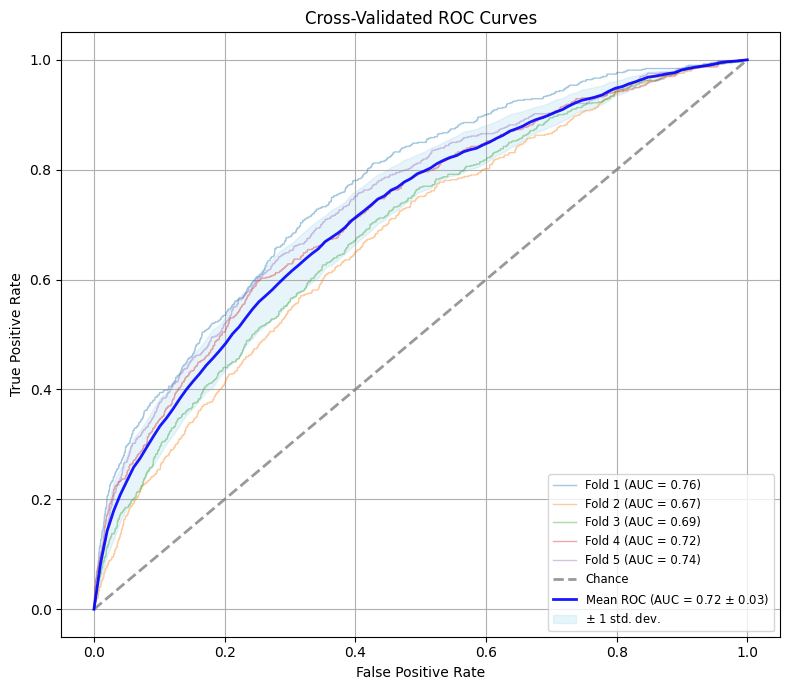


--- Finding Optimal Threshold on Aggregated Probabilities ---
Best threshold to maximize F1-score: 0.6307
  F1-Score at best threshold: 0.2979
  Recall at best threshold:   0.3773
  Precision at best threshold:0.2461

--- Aggregated Performance with Optimal Threshold ---

Aggregated Confusion Matrix (Optimal Threshold):
                 Predicted Non-Extreme (0)  Predicted Extreme (1)
Actual Non-Extreme (0)        27681                      3997  
Actual Extreme (1)            2155                       1304  


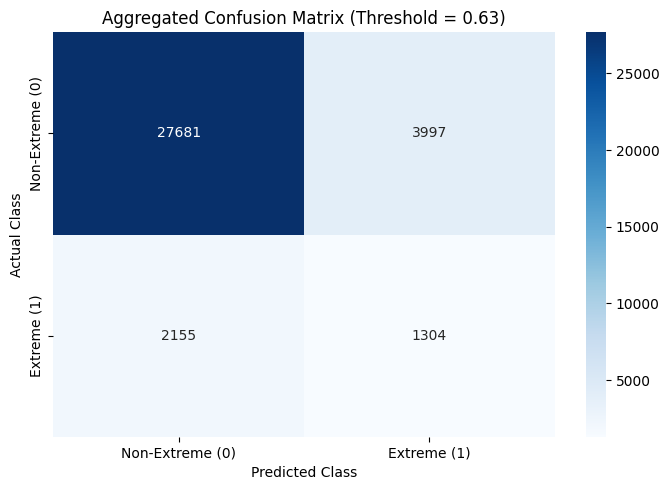


Aggregated Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     31678
           1       0.25      0.38      0.30      3459

    accuracy                           0.82     35137
   macro avg       0.59      0.63      0.60     35137
weighted avg       0.86      0.82      0.84     35137


--- Experiment Finished ---


In [3]:
# -----------------------------------------------------------------------------
# IMPORTS
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
from tqdm.notebook import tqdm # Use standard tqdm if not in a notebook

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve
)
from sklearn.utils import class_weight

import tensorflow as tf
# Imports needed for the model functions (ensure they are included above the functions)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Bidirectional, LSTM, GRU, Dense, Dropout, Masking,
    Conv1D, MaxPooling1D, # For CNN model option
    Attention, AdditiveAttention, GlobalMaxPooling1D # For Attention model option
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Initialize the strategy
strategy = tf.distribute.MirroredStrategy()
# Suppress TensorFlow warnings/logs
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore', category=RuntimeWarning)

# -----------------------------------------------------------------------------
# CONFIGURATION (Define ALL potential hyperparameters needed by ANY model)
# -----------------------------------------------------------------------------
TARGET_COLUMN = 'extreme'
FEATURE_PREFIX = 'prev_72h_'
N_TIMESTEPS = 72
EXCLUDE_COLS = [
    "prev_72h_weather", "prev_72h_snowfall", "prev_72h_snow_depth", "prev_72h_weather_code"
]
FILL_VALUE = 0.0

# --- Model Hyperparameters ---
# CNN + BiRNN specific
FILTERS = 64
KERNEL_SIZE = 5
POOL_SIZE = 2
# RNN specific (used by both model types)
RNN_UNITS = 64      # General RNN units if only one layer needed by CNN model
RNN_UNITS_L1 = 64   # Layer 1 for stacked/Attention models
RNN_UNITS_L2 = 64   # Layer 2 for stacked/Attention models
# Dense layer specific
DENSE_UNITS = 32
# Dropout rates
DROPOUT_CNN = 0.3
DROPOUT_RNN = 0.3   # Used by both
DROPOUT_DENSE = 0.4 # Used by both
# General
LEARNING_RATE = 0.001

# --- Training Hyperparameters ---
EPOCHS = 10
BATCH_SIZE = 256
N_SPLITS = 5
RANDOM_STATE = 42

# Set random seeds
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# -----------------------------------------------------------------------------
# DATA LOADING & PREPARATION (Assuming 'df' is loaded)
# -----------------------------------------------------------------------------
df = pd.read_csv("/kaggle/input/full-dataset-7000-rows/merged_df_copy.csv")
# Placeholder DataFrame for demonstration if 'df' not loaded
if 'df' not in locals():
    print("Warning: DataFrame 'df' not found. Creating placeholder.")
    n_placeholder_rows = 1000; n_extreme_placeholder = 100; placeholder_features = 10
    df = pd.DataFrame({ TARGET_COLUMN: [1]*n_extreme_placeholder + [0]*(n_placeholder_rows-n_extreme_placeholder),
                       **{f"{FEATURE_PREFIX}feat_{i}": [str(list(np.random.rand(N_TIMESTEPS)*10)) for _ in range(n_placeholder_rows)] for i in range(placeholder_features)}})
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("--- Starting Data Preparation ---")
feature_columns = [ col for col in df.columns if col.startswith(FEATURE_PREFIX) and df[col].dtype == 'object' and col not in EXCLUDE_COLS ]
print(f"Found {len(feature_columns)} feature columns.")
if not feature_columns: raise ValueError("No feature columns selected.")
n_features = len(feature_columns)

# (Include the parse_and_pad function here - same as before)
def parse_and_pad(list_str, expected_len=N_TIMESTEPS, fill_value=FILL_VALUE):
    num_list = []
    try:
        if isinstance(list_str, str):
            evaluated = ast.literal_eval(list_str)
            if isinstance(evaluated, list): num_list = evaluated
            else: return [fill_value] * expected_len
        elif isinstance(list_str, list):
            num_list = list_str
        else: return [fill_value] * expected_len

        processed_list = []
        for x in num_list:
             try: processed_list.append(float(x) if pd.notna(x) else fill_value)
             except (ValueError, TypeError): processed_list.append(fill_value)
        num_list = processed_list

        current_len = len(num_list)
        if current_len < expected_len: num_list.extend([fill_value] * (expected_len - current_len))
        elif current_len > expected_len: num_list = num_list[:expected_len]
        return num_list
    except Exception: return [fill_value] * expected_len

n_events = len(df)
X_data = np.zeros((n_events, N_TIMESTEPS, n_features), dtype=np.float32)
print("Parsing lists and building 3D NumPy array...")
for i, feature in enumerate(tqdm(feature_columns, desc="Processing Features")):
    parsed_col = [parse_and_pad(x, N_TIMESTEPS, FILL_VALUE) for x in df[feature].values]
    try: X_data[:, :, i] = np.array(parsed_col, dtype=np.float32)
    except ValueError as e: print(f"\nError processing column {feature}: {e}")

y_data = df[TARGET_COLUMN].values
print(f"Raw data shape: {X_data.shape}, Labels shape: {y_data.shape}")
print(f"Class distribution: {np.bincount(y_data)}")

X_reshaped = X_data.reshape(-1, n_features)
if np.any(np.isnan(X_reshaped)) or np.any(np.isinf(X_reshaped)):
    print("Warning: NaNs/Infs detected before scaling. Replacing with 0.")
    X_reshaped = np.nan_to_num(X_reshaped, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
print("Fitting scaler and transforming data...")
X_scaled_reshaped = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled_reshaped.reshape(n_events, N_TIMESTEPS, n_features)
print(f"Scaled data shape: {X_scaled.shape}")


# -----------------------------------------------------------------------------
# (PLACE YOUR MODEL BUILDING FUNCTIONS HERE - e.g., build_cnn_birnn_model, build_birnn_attention_model)
# -----------------------------------------------------------------------------
# Example: Paste the build_birnn_attention_model function from Section 1 here.
# Or paste the build_cnn_birnn_model function if you prefer that one.


# -----------------------------------------------------------------------------
# STRATIFIED K-FOLD CROSS-VALIDATION
# -----------------------------------------------------------------------------
print(f"\n--- Starting {N_SPLITS}-Fold Stratified Cross-Validation ---")
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Store results
fold_metrics = []
all_y_true = []
all_y_pred_proba = []

# ROC Curve data
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
fig_roc, ax_roc = plt.subplots(figsize=(8, 7))

for fold, (train_index, test_index) in enumerate(skf.split(X_scaled, y_data)):
    print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")
    X_train_fold, X_test_fold = X_scaled[train_index], X_scaled[test_index]
    y_train_fold, y_test_fold = y_data[train_index], y_data[test_index]

    print(f"Train shape: {X_train_fold.shape}, Test shape: {X_test_fold.shape}")
    print(f"Train labels distribution: {np.bincount(y_train_fold)}")
    print(f"Test labels distribution: {np.bincount(y_test_fold)}")

    # --- Calculate Class Weights ---
    classes = np.unique(y_train_fold)
    weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train_fold)
    class_weights_dict = dict(zip(classes, weights))
    print(f"Class Weights: {class_weights_dict}")

    # --- Build and Train ---
    input_shape_fold = (N_TIMESTEPS, n_features)

    # *** SELECT THE MODEL BUILDING FUNCTION HERE ***
    # Choose ONE of the following lines depending on the model you want to run:
    # model = build_cnn_birnn_model(input_shape=input_shape_fold, use_gru=True, learning_rate=LEARNING_RATE) # CNN+BiGRU
    # Open a strategy scope.
    with strategy.scope():
        model = build_birnn_attention_model(input_shape=input_shape_fold, use_gru=True, learning_rate=LEARNING_RATE)
        if fold == 0: model.summary()
    
        early_stopping = EarlyStopping( monitor='val_recall', patience=8, mode='max', verbose=1, restore_best_weights=True )
    
        print("Training model with class weights...")
        history = model.fit(
            X_train_fold, y_train_fold,
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(X_test_fold, y_test_fold),
            callbacks=[early_stopping],
            class_weight=class_weights_dict, # Apply weights
            verbose=1
        )
    
        print("Evaluating model on test fold...")
        y_pred_proba_fold = model.predict(X_test_fold, batch_size=BATCH_SIZE).flatten()
        y_pred_labels_fold = (y_pred_proba_fold > 0.5).astype(int)
    
        # Calculate metrics
        acc = accuracy_score(y_test_fold, y_pred_labels_fold)
        prec = precision_score(y_test_fold, y_pred_labels_fold, zero_division=0)
        rec = recall_score(y_test_fold, y_pred_labels_fold, zero_division=0)
        f1 = f1_score(y_test_fold, y_pred_labels_fold, zero_division=0)
        try: roc_auc = roc_auc_score(y_test_fold, y_pred_proba_fold)
        except ValueError: roc_auc = np.nan
    
        fold_metrics.append({'Fold': fold+1, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC': roc_auc})
        print(f"Fold {fold+1} Results (Thr=0.5): Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, AUC={roc_auc:.4f}")
    
        # Store predictions
        all_y_true.extend(y_test_fold)
        all_y_pred_proba.extend(y_pred_proba_fold)
    
        # ROC Curve data for this fold
        fpr, tpr, _ = roc_curve(y_test_fold, y_pred_proba_fold)
        interp_tpr = np.interp(mean_fpr, fpr, tpr); interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc if not np.isnan(roc_auc) else 0.0)
        ax_roc.plot(fpr, tpr, lw=1, alpha=0.4, label=f'Fold {fold+1} (AUC = {roc_auc:.2f})')
    
        # tf.keras.backend.clear_session() # Clear session

# -----------------------------------------------------------------------------
# AGGREGATE RESULTS, PLOT MEAN ROC, THRESHOLD TUNING, OPTIMAL EVALUATION
# (This part remains exactly the same as the previous 'complete code' answer)
# -----------------------------------------------------------------------------

# --- AGGREGATE CROSS-VALIDATION RESULTS ---
metrics_df = pd.DataFrame(fold_metrics)
print("\n--- Cross-Validation Summary (Metrics @ Thr=0.5) ---")
print(metrics_df.set_index('Fold'))
print("\nAverage Metrics (Thr=0.5):")
avg_metrics = { 'Accuracy': np.mean(metrics_df['Accuracy']), 'Precision': np.mean(metrics_df['Precision']),
                'Recall': np.mean(metrics_df['Recall']), 'F1': np.mean(metrics_df['F1']),
                'ROC_AUC': np.nanmean(metrics_df['ROC_AUC']) }
std_metrics = { 'Accuracy': np.std(metrics_df['Accuracy']), 'Precision': np.std(metrics_df['Precision']),
                'Recall': np.std(metrics_df['Recall']), 'F1': np.std(metrics_df['F1']),
                'ROC_AUC': np.nanstd(metrics_df['ROC_AUC']) }
for metric in avg_metrics: print(f"  {metric}: {avg_metrics[metric]:.4f} +/- {std_metrics[metric]:.4f}")

# --- PLOT MEAN ROC CURVE ---
ax_roc.plot([0, 1], [0, 1], linestyle='--', lw=2, color='grey', label='Chance', alpha=.8)
mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr); std_auc = np.std(aucs)
ax_roc.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f} $\\pm$ {std_auc:.2f})', lw=2, alpha=.9)
std_tpr = np.std(tprs, axis=0); tprs_upper = np.minimum(mean_tpr + std_tpr, 1); tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax_roc.fill_between(mean_fpr, tprs_lower, tprs_upper, color='skyblue', alpha=.2, label=r'$\pm$ 1 std. dev.')
ax_roc.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05], xlabel="False Positive Rate", ylabel="True Positive Rate", title="Cross-Validated ROC Curves")
ax_roc.legend(loc="lower right", fontsize='small'); plt.grid(True); plt.tight_layout(); plt.show()

# --- THRESHOLD TUNING & OPTIMAL EVALUATION ---
print("\n--- Finding Optimal Threshold on Aggregated Probabilities ---")
all_y_true = np.array(all_y_true); all_y_pred_proba = np.array(all_y_pred_proba)
precision_curve, recall_curve, threshold_curve = precision_recall_curve(all_y_true, all_y_pred_proba)
f1_scores = 2 * recall_curve * precision_curve / (recall_curve + precision_curve + 1e-9); f1_scores = np.nan_to_num(f1_scores)
best_f1_idx = np.argmax(f1_scores[:-1]); best_threshold = threshold_curve[best_f1_idx]
best_f1 = f1_scores[best_f1_idx]; best_precision = precision_curve[best_f1_idx]; best_recall = recall_curve[best_f1_idx]
print(f"Best threshold to maximize F1-score: {best_threshold:.4f}")
print(f"  F1-Score at best threshold: {best_f1:.4f}"); print(f"  Recall at best threshold:   {best_recall:.4f}"); print(f"  Precision at best threshold:{best_precision:.4f}")

print("\n--- Aggregated Performance with Optimal Threshold ---")
all_y_pred_labels_optimal = (all_y_pred_proba > best_threshold).astype(int)
cm_agg_optimal = confusion_matrix(all_y_true, all_y_pred_labels_optimal)
tn_opt, fp_opt, fn_opt, tp_opt = cm_agg_optimal.ravel()
print("\nAggregated Confusion Matrix (Optimal Threshold):")
print(f"                 Predicted Non-Extreme (0)  Predicted Extreme (1)"); print(f"Actual Non-Extreme (0)        {tn_opt:<6}                     {fp_opt:<6}"); print(f"Actual Extreme (1)            {fn_opt:<6}                     {tp_opt:<6}")
plt.figure(figsize=(7, 5)); sns.heatmap(cm_agg_optimal, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Extreme (0)', 'Extreme (1)'], yticklabels=['Non-Extreme (0)', 'Extreme (1)'])
plt.title(f'Aggregated Confusion Matrix (Threshold = {best_threshold:.2f})'); plt.ylabel('Actual Class'); plt.xlabel('Predicted Class'); plt.tight_layout(); plt.show()
print("\nAggregated Classification Report (Optimal Threshold):"); report_agg_optimal = classification_report(all_y_true, all_y_pred_labels_optimal); print(report_agg_optimal)

# --- FINALIZATION ---
print("\n--- Experiment Finished ---")

In [4]:
import pandas as pd
import numpy as np
import ast
from tqdm.notebook import tqdm # Or standard tqdm

# --- Helper function to safely process list strings ---
# (Same as used before, ensure it's defined)
def parse_list_string(data, fill_value=0.0):
    """Safely parses list strings or lists, returning a list of floats or None."""
    if isinstance(data, list): # Already a list
        num_list = data
    elif isinstance(data, str):
        try:
            evaluated = ast.literal_eval(data)
            if isinstance(evaluated, list):
                num_list = evaluated
            else: return None # Not a list after eval
        except (ValueError, SyntaxError, TypeError):
            return None # Parsing failed
    else:
        return None # Not a string or list

    # Convert to float, handle NaNs/errors within the list
    processed_list = []
    for x in num_list:
        try:
            processed_list.append(float(x) if pd.notna(x) else np.nan) # Keep NaNs for now
        except (ValueError, TypeError):
            processed_list.append(np.nan) # Mark conversion errors as NaN
    return processed_list

# --- Functions to calculate summary statistics (handle NaNs) ---
# Using numpy functions that handle NaNs
def calculate_mean(num_list):
    if num_list and len(num_list) > 0: return np.nanmean(num_list)
    return np.nan
def calculate_std(num_list):
    if num_list and len(num_list) > 1: return np.nanstd(num_list)
    return np.nan
def calculate_min(num_list):
    if num_list and len(num_list) > 0: return np.nanmin(num_list)
    return np.nan
def calculate_max(num_list):
    if num_list and len(num_list) > 0: return np.nanmax(num_list)
    return np.nan
def calculate_trend(num_list):
    # Filter out NaNs for trend calculation
    if not num_list: return np.nan
    y = np.array([x for x in num_list if pd.notna(x)])
    if len(y) >= 2:
        x = np.arange(len(y))
        try:
            coeffs = np.polyfit(x, y, 1)
            return coeffs[0] # Return slope
        except (np.linalg.LinAlgError, ValueError):
             return np.nan # Handle fitting errors
    return np.nan

# --- Main Feature Engineering Function ---
def engineer_xgb_features(df_fold, sequence_feature_cols, target_col, fill_value=0.0):
    """
    Engineers summary features from sequence columns for XGBoost.

    Args:
        df_fold (pd.DataFrame): DataFrame subset (train or test fold).
        sequence_feature_cols (list): List of column names containing sequences.
        target_col (str): Name of the target variable column.
        fill_value (float): Value used if parsing fails completely (though NaN is preferred internally).

    Returns:
        tuple: (X_engineered, y_fold)
            X_engineered (pd.DataFrame): DataFrame with engineered features.
            y_fold (pd.Series): Target variable series.
    """
    print(f"Engineering features for {len(df_fold)} samples...")
    df_eng = df_fold.copy()
    engineered_feature_names = []

    # Create engineered features
    for feature in tqdm(sequence_feature_cols, desc="Engineering Features"):
        base_name = feature.replace(FEATURE_PREFIX, "") # Get cleaner base name
        parsed_lists = df_eng[feature].apply(lambda x: parse_list_string(x, fill_value=np.nan)) # Use NaN fill

        # Calculate stats safely
        df_eng[f"{base_name}_mean"] = parsed_lists.apply(calculate_mean)
        df_eng[f"{base_name}_std"] = parsed_lists.apply(calculate_std)
        df_eng[f"{base_name}_min"] = parsed_lists.apply(calculate_min)
        df_eng[f"{base_name}_max"] = parsed_lists.apply(calculate_max)
        df_eng[f"{base_name}_trend"] = parsed_lists.apply(calculate_trend)

        engineered_feature_names.extend([
            f"{base_name}_mean", f"{base_name}_std", f"{base_name}_min",
            f"{base_name}_max", f"{base_name}_trend"
        ])

    # Select only the engineered features and target
    # Also include any original non-sequence, non-target numeric features if desired
    # For now, just using engineered ones. Add others from df_fold if needed.
    X_engineered = df_eng[engineered_feature_names]
    y_fold = df_eng[target_col]

    # Optional: Handle any remaining NaNs produced by feature engineering
    # XGBoost can handle NaNs internally, so this might not be needed,
    # but explicit handling can sometimes be safer depending on XGBoost version/settings.
    # X_engineered = X_engineered.fillna(X_engineered.median()) # Example: Fill with median

    print(f"Finished engineering. Shape of X: {X_engineered.shape}")
    return X_engineered, y_fold


--- Starting 5-Fold Stratified Cross-Validation (XGBoost) ---

--- Fold 1/5 ---
Train samples: 28109, Test samples: 7028
Train labels distribution: [25342  2767]
Test labels distribution: [6336  692]
XGBoost scale_pos_weight: 9.1587
Engineering features for 28109 samples...


Engineering Features:   0%|          | 0/27 [00:00<?, ?it/s]

<ipython-input-4-f29d58372383>:87: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f"{base_name}_min"] = parsed_lists.apply(calculate_min)
<ipython-input-4-f29d58372383>:88: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f"{base_name}_max"] = parsed_lists.apply(calculate_max)
<ipython-input-4-f29d58372383>:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) ins

Finished engineering. Shape of X: (28109, 135)
Engineering features for 7028 samples...


<ipython-input-4-f29d58372383>:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f"{base_name}_trend"] = parsed_lists.apply(calculate_trend)


...

Finished engineering. Shape of X: (28110, 135)
Engineering features for 7027 samples...


<ipython-input-4-f29d58372383>:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f"{base_name}_trend"] = parsed_lists.apply(calculate_trend)


Engineering Features:   0%|          | 0/27 [00:00<?, ?it/s]

<ipython-input-4-f29d58372383>:87: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f"{base_name}_min"] = parsed_lists.apply(calculate_min)
<ipython-input-4-f29d58372383>:88: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[f"{base_name}_max"] = parsed_lists.apply(calculate_max)
<ipython-input-4-f29d58372383>:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) ins

Finished engineering. Shape of X: (7027, 135)
Scaled engineered features shapes: Train=(28110, 135), Test=(7027, 135)
Training XGBoost model...
[0]	validation_0-aucpr:0.24897	validation_1-aucpr:0.20545
[1]	validation_0-aucpr:0.27978	validation_1-aucpr:0.21914
[2]	validation_0-aucpr:0.32759	validation_1-aucpr:0.24455
[3]	validation_0-aucpr:0.34736	validation_1-aucpr:0.25180
[4]	validation_0-aucpr:0.35531	validation_1-aucpr:0.25727
[5]	validation_0-aucpr:0.36803	validation_1-aucpr:0.26619
[6]	validation_0-aucpr:0.37250	validation_1-aucpr:0.27141
[7]	validation_0-aucpr:0.37289	validation_1-aucpr:0.27055
[8]	validation_0-aucpr:0.38121	validation_1-aucpr:0.27698
[9]	validation_0-aucpr:0.39068	validation_1-aucpr:0.28034
[10]	validation_0-aucpr:0.39601	validation_1-aucpr:0.28270
[11]	validation_0-aucpr:0.39901	validation_1-aucpr:0.28150
[12]	validation_0-aucpr:0.40695	validation_1-aucpr:0.28432
[13]	validation_0-aucpr:0.41356	validation_1-aucpr:0.28683
[14]	validation_0-aucpr:0.41673	validati

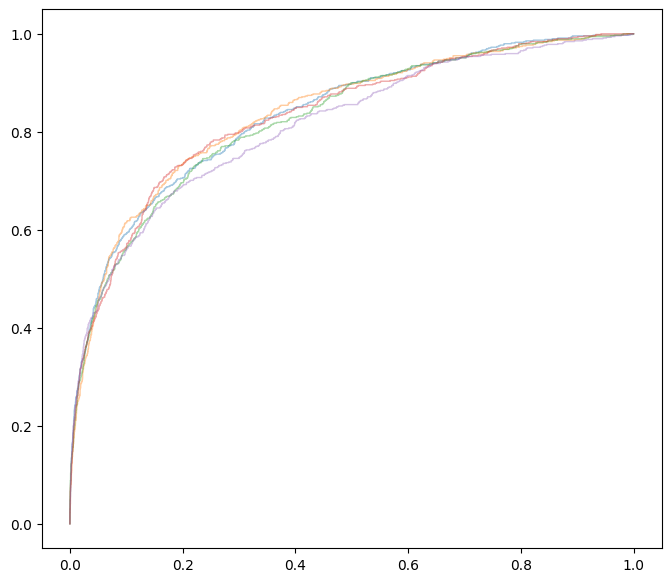

In [6]:
# --- Necessary Imports for this section ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve
)
import xgboost as xgb # Make sure xgboost is imported
from tqdm.notebook import tqdm # Or standard tqdm

# --- Assume these are defined before this block ---
# df: Your main DataFrame
# TARGET_COLUMN: Name of the target column
# feature_columns: List of sequence column names to engineer from
# N_SPLITS, RANDOM_STATE: CV configuration
# engineer_xgb_features: The feature engineering function from previous step
# xgb_params: Dictionary of XGBoost parameters (can define default here or inside loop)

# --- 5. Stratified K-Fold Cross-Validation for XGBoost ---
print(f"\n--- Starting {N_SPLITS}-Fold Stratified Cross-Validation (XGBoost) ---")
# Use StratifiedKFold on the indices of the DataFrame
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Store results from each fold
fold_metrics = []
all_y_true = []
all_y_pred_proba = []

# ROC Curve data
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
fig_roc, ax_roc = plt.subplots(figsize=(8, 7)) # Create figure for ROC curves

# Use df.index for splitting the DataFrame itself
for fold, (train_index, test_index) in enumerate(skf.split(df.index, df[TARGET_COLUMN])):
    print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")

    # Get DataFrame subsets for this fold
    df_train_fold = df.iloc[train_index]
    df_test_fold = df.iloc[test_index]

    # Get corresponding labels directly from the fold's target column
    y_train_fold = df_train_fold[TARGET_COLUMN].values
    y_test_fold = df_test_fold[TARGET_COLUMN].values

    print(f"Train samples: {len(df_train_fold)}, Test samples: {len(df_test_fold)}")
    print(f"Train labels distribution: {np.bincount(y_train_fold)}")
    print(f"Test labels distribution: {np.bincount(y_test_fold)}")

    # --- Calculate scale_pos_weight for XGBoost ---
    count_neg = np.sum(y_train_fold == 0)
    count_pos = np.sum(y_train_fold == 1)
    # Handle potential division by zero if a fold has no positive samples (unlikely with stratification but safe)
    scale_pos_weight_xgb = count_neg / count_pos if count_pos > 0 else 1
    print(f"XGBoost scale_pos_weight: {scale_pos_weight_xgb:.4f}")

    # --- Engineer Features ---
    # Call the feature engineering function on the DataFrame folds
    X_train_eng, y_train_fold_eng = engineer_xgb_features(df_train_fold, feature_columns, TARGET_COLUMN)
    X_test_eng, y_test_fold_eng = engineer_xgb_features(df_test_fold, feature_columns, TARGET_COLUMN)
    # y_train_fold_eng and y_test_fold_eng should match y_train_fold and y_test_fold

    # --- Handle Potential NaNs from Feature Engineering ---
    # Option 1: XGBoost handles NaNs internally (often preferred) - do nothing extra
    # Option 2: Explicitly fill NaNs (e.g., with median or 0)
    # if X_train_eng.isnull().any().any():
    #     print("Warning: NaNs found in engineered training features. Filling with median.")
    #     train_median = X_train_eng.median()
    #     X_train_eng = X_train_eng.fillna(train_median)
    #     X_test_eng = X_test_eng.fillna(train_median) # Use train median for test set

    # --- Scale Engineered Features ---
    scaler_xgb = StandardScaler()
    X_train_scaled = scaler_xgb.fit_transform(X_train_eng)
    X_test_scaled = scaler_xgb.transform(X_test_eng)
    print(f"Scaled engineered features shapes: Train={X_train_scaled.shape}, Test={X_test_scaled.shape}")

    # --- Define XGBoost Parameters (can also define outside loop if static) ---
    current_xgb_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr', # Area under PR Curve good for imbalance
        'eta': 0.05,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 1,
        'gamma': 0.1,
        'lambda': 1,
        'alpha': 0,
        'scale_pos_weight': scale_pos_weight_xgb, # Use calculated weight for this fold
        'use_label_encoder': False,
        'seed': RANDOM_STATE + fold # Add fold to seed for slight variation if desired
    }

    # --- Define and Train XGBoost Model ---
    model = xgb.XGBClassifier(**current_xgb_params, n_estimators=1000,  early_stopping_rounds=50   ) # High n_estimators, rely on early stopping

    print("Training XGBoost model...")
    eval_set = [(X_train_scaled, y_train_fold_eng), (X_test_scaled, y_test_fold_eng)]

    model.fit(X_train_scaled, y_train_fold_eng,
              eval_set=eval_set,
    
              verbose=True) # Suppress XGBoost training output

    print(f"Best iteration: {model.best_iteration}, Best score ({current_xgb_params['eval_metric']}): {model.best_score:.4f}")

    # --- Evaluate and Store Results ---
    print("Evaluating model on test fold...")
    y_pred_proba_fold = model.predict_proba(X_test_scaled)[:, 1] # Prob for class 1
    y_pred_labels_fold = (y_pred_proba_fold > 0.5).astype(int) # Initial threshold

    # Calculate metrics using test fold ground truth
    acc = accuracy_score(y_test_fold_eng, y_pred_labels_fold)
    prec = precision_score(y_test_fold_eng, y_pred_labels_fold, zero_division=0)
    rec = recall_score(y_test_fold_eng, y_pred_labels_fold, zero_division=0)
    f1 = f1_score(y_test_fold_eng, y_pred_labels_fold, zero_division=0)
    try:
        # Ensure probabilities are valid before calculating ROC AUC
        if np.any(np.isnan(y_pred_proba_fold)) or np.any(np.isinf(y_pred_proba_fold)):
             raise ValueError("NaN or Inf found in predicted probabilities.")
        if len(np.unique(y_test_fold_eng)) < 2:
             raise ValueError("Only one class present in y_true. ROC AUC score is not defined in that case.")
        roc_auc = roc_auc_score(y_test_fold_eng, y_pred_proba_fold)
    except ValueError as e:
        print(f"Warning: ROC AUC calculation error for fold {fold+1}: {e}")
        roc_auc = np.nan # Assign NaN if AUC cannot be computed


    fold_metrics.append({'Fold': fold+1, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC': roc_auc})
    print(f"Fold {fold+1} XGB Results (Thr=0.5): Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, AUC={roc_auc if not np.isnan(roc_auc) else 'N/A'}")

    # Store predictions for overall evaluation and threshold tuning
    all_y_true.extend(y_test_fold_eng)
    all_y_pred_proba.extend(y_pred_proba_fold)

    # ROC Curve data for this fold (handle potential NaN AUC)
    if not np.isnan(roc_auc):
        fpr, tpr, _ = roc_curve(y_test_fold_eng, y_pred_proba_fold)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc)
        ax_roc.plot(fpr, tpr, lw=1, alpha=0.4, label=f'Fold {fold+1} XGB (AUC = {roc_auc:.2f})')
    else:
        # Don't add to tprs/aucs list if AUC is NaN, maybe plot differently or skip
        print(f"Skipping ROC curve plotting for Fold {fold+1} due to AUC calculation issue.")
        # Optionally add a placeholder to keep list lengths consistent if needed elsewhere
        # tprs.append(np.zeros_like(mean_fpr)) # Example placeholder
        # aucs.append(0.0) # Example placeholder

# --- End of Loop ---

# (The rest of your code for aggregating results, plotting mean ROC,
#  threshold tuning, and optimal evaluation should follow here, using
#  the `fold_metrics`, `all_y_true`, `all_y_pred_proba`, `tprs`, `aucs` lists)

## Trying traditional models

## with feature engineering

In [5]:
# Core Libraries
import pandas as pd
import numpy as np
import time
import warnings
import ast
import pickle # Or use joblib for potentially larger objects
import os

# Scikit-learn
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils import class_weight # Needed for RF/LR weights if not using built-in

# Boosting Libraries
import xgboost as xgb
import lightgbm as lgb

# Plotting & Utilities
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm # Use standard tqdm if not in notebook

# --- Configuration ---
# Data & Feature Engineering
TARGET_COLUMN = 'extreme'
FEATURE_PREFIX = 'prev_72h_'
EXCLUDE_COLS = [ # List of original sequence columns to exclude from feature engineering
    "prev_72h_weather", "prev_72h_snowfall", "prev_72h_snow_depth", "prev_72h_weather_code"
]
ENGINEERED_FEATURES_FILE = 'engineered_features_cache.pkl' # File to save/load engineered data

# Cross-Validation & Training
N_SPLITS = 5
RANDOM_STATE = 42
METRIC_TO_OPTIMIZE_THRESHOLD = 'f1' # 'f1' or 'recall' etc.

# Model Settings
N_ESTIMATORS_TREES = 200 # For RF, XGB, LGB
MAX_ITER_LOGREG = 1000   # For Logistic Regression convergence

# GPU Settings (Attempt to use if available)
# Note: Requires properly installed GPU drivers and compatible libraries (CUDA, cuDNN for XGB/LGB)
USE_GPU = True # Set to False to force CPU

# Set random seeds
np.random.seed(RANDOM_STATE)
# tf.random.set_seed(RANDOM_STATE) # Not using TF here

# Suppress warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
# Optional: Suppress XGB/LGB verbosity during training if desired
# import logging
# logging.getLogger('xgboost').setLevel(logging.ERROR)
# logging.getLogger('lightgbm').setLevel(logging.ERROR)

print("Configuration loaded.")

Configuration loaded.


In [6]:
# Load your primary DataFrame 'df' here
# Example:
try:
    df = pd.read_csv('/kaggle/input/full-dataset-7000-rows/merged_df_copy.csv') # Replace with your actual data file
    print(f"Original DataFrame loaded. Shape: {df.shape}")
    print(f"Class distribution:\n{df[TARGET_COLUMN].value_counts(normalize=True)}")
except FileNotFoundError:
    print("Error: Data file not found. Please load your DataFrame as 'df'.")
    # You might want to exit or use placeholder data if the file isn't found
    # Placeholder DataFrame for demonstration if not loaded
    if 'df' not in locals():
        print("Warning: DataFrame 'df' not found. Creating placeholder.")
        n_placeholder_rows = 1000; n_extreme_placeholder = 100; placeholder_features = 10
        df = pd.DataFrame({ TARGET_COLUMN: [1]*n_extreme_placeholder + [0]*(n_placeholder_rows-n_extreme_placeholder),
                           **{f"{FEATURE_PREFIX}feat_{i}": [str(list(np.random.rand(72)*10)) for _ in range(n_placeholder_rows)] for i in range(placeholder_features)}})
        df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

<ipython-input-6-e87d437df80e>:4: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/full-dataset-7000-rows/merged_df_copy.csv') # Replace with your actual data file


Original DataFrame loaded. Shape: (35137, 50)
Class distribution:
extreme
0    0.901557
1    0.098443
Name: proportion, dtype: float64


In [7]:
# --- Feature Engineering Helpers (Define ONCE) ---
def parse_list_string(data, fill_value=np.nan):
    """Safely parses list strings or lists, returning a list of floats or None."""
    if isinstance(data, list): num_list = data
    elif isinstance(data, str):
        try:
            evaluated = ast.literal_eval(data)
            if isinstance(evaluated, list): num_list = evaluated
            else: return None
        except (ValueError, SyntaxError, TypeError): return None
    else: return None
    processed_list = []
    for x in num_list:
        try: processed_list.append(float(x) if pd.notna(x) else fill_value)
        except (ValueError, TypeError): processed_list.append(fill_value)
    return processed_list

def calculate_mean(num_list):
    if num_list: return np.nanmean([x for x in num_list if pd.notna(x)]) # Ensure NaN handling
    return np.nan
def calculate_std(num_list):
     if num_list:
        valid_list = [x for x in num_list if pd.notna(x)]
        if len(valid_list) > 1: return np.nanstd(valid_list)
     return np.nan
def calculate_min(num_list):
    if num_list:
        valid_list = [x for x in num_list if pd.notna(x)]
        if valid_list: return np.nanmin(valid_list)
    return np.nan
def calculate_max(num_list):
     if num_list:
        valid_list = [x for x in num_list if pd.notna(x)]
        if valid_list: return np.nanmax(valid_list)
     return np.nan
def calculate_trend(num_list):
    if not num_list: return np.nan
    y = np.array([x for x in num_list if pd.notna(x)])
    if len(y) >= 2:
        x = np.arange(len(y))
        try:
            coeffs = np.polyfit(x, y, 1); return coeffs[0]
        except (np.linalg.LinAlgError, ValueError): return np.nan
    return np.nan

def engineer_features(input_df, sequence_cols, target_col):
    """Engineers summary features and returns X, y."""
    print(f"Starting feature engineering for {len(input_df)} samples...")
    df_eng = input_df.copy()
    engineered_feature_names = []
    for feature in tqdm(sequence_cols, desc="Engineering Features"):
        base_name = feature.replace(FEATURE_PREFIX, "")
        parsed_lists = df_eng[feature].apply(parse_list_string) # Uses NaN fill default
        df_eng[f"{base_name}_mean"] = parsed_lists.apply(calculate_mean)
        df_eng[f"{base_name}_std"] = parsed_lists.apply(calculate_std)
        df_eng[f"{base_name}_min"] = parsed_lists.apply(calculate_min)
        df_eng[f"{base_name}_max"] = parsed_lists.apply(calculate_max)
        df_eng[f"{base_name}_trend"] = parsed_lists.apply(calculate_trend)
        engineered_feature_names.extend([ f"{base_name}_mean", f"{base_name}_std", f"{base_name}_min", f"{base_name}_max", f"{base_name}_trend"])

    # Include original numeric features NOT used for sequence engineering (if any)
    original_numeric_cols = [ col for col in input_df.select_dtypes(include=np.number).columns
                              if col != target_col and not col.startswith(FEATURE_PREFIX)]
    print(f"Including {len(original_numeric_cols)} original numeric features: {original_numeric_cols}")
    all_feature_names = engineered_feature_names + original_numeric_cols

    X_engineered = df_eng[all_feature_names]
    y_target = df_eng[target_col].values # Get as numpy array

    # --- Handle NaNs ---
    # Check for NaNs after engineering
    nan_counts = X_engineered.isnull().sum()
    cols_with_nans = nan_counts[nan_counts > 0]
    if not cols_with_nans.empty:
        print(f"\nWarning: NaNs found after feature engineering in columns:")
        print(cols_with_nans)
        # Strategy: Fill NaNs (e.g., with median or 0). Median is often safer.
        # Calculate medians based ONLY on the data being processed (avoids data leak if done globally)
        print("Filling NaNs with column medians...")
        col_medians = X_engineered.median()
        X_engineered = X_engineered.fillna(col_medians)
        # Check if any NaNs remain (e.g., if a whole column was NaN)
        if X_engineered.isnull().any().any():
             print("Warning: NaNs still remain after median fill. Filling remaining with 0.")
             X_engineered = X_engineered.fillna(0) # Fallback fill
    else:
        print("No NaNs found after feature engineering.")


    print(f"Finished engineering. Shape of X: {X_engineered.shape}, Shape of y: {y_target.shape}")
    return X_engineered, y_target

# --- Execute Feature Engineering ---
# Check if cached file exists
if os.path.exists(ENGINEERED_FEATURES_FILE):
    print(f"Loading cached engineered features from {ENGINEERED_FEATURES_FILE}...")
    try:
        with open(ENGINEERED_FEATURES_FILE, 'rb') as f:
            X_eng, y_eng = pickle.load(f)
        print("Loaded successfully.")
        # Optional: Sanity check shapes or data types if needed
        if not isinstance(X_eng, pd.DataFrame) or not isinstance(y_eng, np.ndarray):
             print("Warning: Loaded data might not be in expected format. Re-engineering...")
             raise TypeError("Incorrect data types loaded from pickle.")
        if len(X_eng) != len(df):
             print("Warning: Cached data length mismatch. Re-engineering...")
             raise ValueError("Cached data length mismatch.")

    except Exception as e:
        print(f"Error loading cache or cache invalid: {e}. Re-engineering features...")
        sequence_feature_cols = [col for col in df.columns if col.startswith(FEATURE_PREFIX) and col not in EXCLUDE_COLS]
        X_eng, y_eng = engineer_features(df, sequence_feature_cols, TARGET_COLUMN)
        print(f"Saving engineered features to {ENGINEERED_FEATURES_FILE}...")
        with open(ENGINEERED_FEATURES_FILE, 'wb') as f:
            pickle.dump((X_eng, y_eng), f)
else:
    print("No cached file found. Engineering features...")
    sequence_feature_cols = [col for col in df.columns if col.startswith(FEATURE_PREFIX) and col not in EXCLUDE_COLS]
    X_eng, y_eng = engineer_features(df, sequence_feature_cols, TARGET_COLUMN)
    print(f"Saving engineered features to {ENGINEERED_FEATURES_FILE}...")
    with open(ENGINEERED_FEATURES_FILE, 'wb') as f:
        pickle.dump((X_eng, y_eng), f)

# Display engineered data info
print(f"\nEngineered Features Info:")
X_eng.info()
print(f"\nTarget Variable Info:")
print(pd.Series(y_eng).value_counts())

Loading cached engineered features from engineered_features_cache.pkl...
Loaded successfully.

Engineered Features Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35137 entries, 0 to 35136
Columns: 141 entries, temperature_2m_mean to event_id
dtypes: float64(139), int64(2)
memory usage: 37.8 MB

Target Variable Info:
0    31678
1     3459
Name: count, dtype: int64


In [10]:
# --- (Keep Imports, Config, Data Loading, Feature Engineering Cells the same) ---

# --- Cell 5: Model Definitions and Cross-Validation Loop (with SMOTE) ---

# --- Necessary Imports for this section ---
# ... (Keep previous imports) ...
from imblearn.over_sampling import SMOTE # Import SMOTE

# --- Model Definitions ---
# (Keep your models_to_run dictionary definition - BUT REMOVE imbalance params initially)

models_to_run = {}

# 1. Logistic Regression (Remove class_weight)
models_to_run['LogisticRegression_SMOTE'] = LogisticRegression(
    solver='liblinear',
    random_state=RANDOM_STATE,
    # class_weight='balanced', # REMOVE or comment out when using SMOTE
    max_iter=MAX_ITER_LOGREG
)

# 2. Random Forest (Remove class_weight)
models_to_run['RandomForest_SMOTE'] = RandomForestClassifier(
    n_estimators=N_ESTIMATORS_TREES,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=3,
    # class_weight='balanced_subsample', # REMOVE or comment out
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 3. AdaBoost (No change needed here, didn't have weight param before)
models_to_run['AdaBoost_SMOTE'] = AdaBoostClassifier(
    n_estimators=N_ESTIMATORS_TREES,
    random_state=RANDOM_STATE,
    learning_rate=0.1
)

# --- GPU Accelerated Models ---
# (Keep xgb_gpu_params, lgb_gpu_params logic the same)
xgb_gpu_params = {}
lgb_gpu_params = {}
if USE_GPU:
    try:
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            print(f"GPUs Available: {gpus}. Configuring GPU usage.")
            xgb_gpu_params = {'tree_method': 'hist', 'device': 'cuda'}
            lgb_gpu_params = {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}
        else: raise RuntimeError("No GPU")
    except Exception as e:
        print(f"GPU check/config failed: {e}. Using CPU for XGBoost/LightGBM.")
        xgb_gpu_params = {'tree_method': 'hist'}
        lgb_gpu_params = {}

# 4. XGBoost (Remove scale_pos_weight from base params)
models_to_run['XGBoost_SMOTE'] = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    eta=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
    min_child_weight=1, gamma=0.1, reg_lambda=1, reg_alpha=0,
    # scale_pos_weight=scale_pos_weight_xgb, # REMOVE from base config
    use_label_encoder=False, seed=RANDOM_STATE,
    n_estimators=N_ESTIMATORS_TREES,
    early_stopping_rounds=50,
    **xgb_gpu_params
)

# --- Cross-Validation Setup ---
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
all_models_results = {}
mean_fpr = np.linspace(0, 1, 100)

# --- Run Cross-Validation for Each Model ---
for model_name, model_instance in models_to_run.items():
    print(f"\n===== Running Cross-Validation for: {model_name} (with SMOTE) =====")
    fold_metrics = []
    model_all_y_true = []
    model_all_y_pred_proba = []
    model_tprs = []
    model_aucs = []
    start_time_model = time.time()

    for fold, (train_index, test_index) in enumerate(skf.split(X_eng, y_eng)):
        print(f"\n--- Fold {fold+1}/{N_SPLITS} for {model_name} ---")
        X_train_fold, X_test_fold = X_eng.iloc[train_index], X_eng.iloc[test_index]
        y_train_fold, y_test_fold = y_eng[train_index], y_eng[test_index]

        # --- Apply SMOTE to Training Data ONLY ---
        print(f"Original train shapes: X={X_train_fold.shape}, y={y_train_fold.shape}")
        print(f"Original train distribution: {np.bincount(y_train_fold)}")
        smote = SMOTE(random_state=RANDOM_STATE + fold, sampling_strategy='auto', k_neighbors=5) # Adjust k_neighbors if needed
        try:
            X_train_resampled, y_train_resampled = smote.fit_resample(X_train_fold, y_train_fold)
            print(f"Resampled train shapes: X={X_train_resampled.shape}, y={y_train_resampled.shape}")
            print(f"Resampled train distribution: {np.bincount(y_train_resampled)}")
        except Exception as e:
            print(f"SMOTE failed for fold {fold+1}: {e}. Skipping fold.")
            continue # Skip to next fold if SMOTE fails

        # --- Scale Features AFTER Resampling ---
        # Fit scaler ONLY on the resampled training data
        scaler = StandardScaler()
        X_train_scaled_resampled = scaler.fit_transform(X_train_resampled)
        # Transform the ORIGINAL test data using the same scaler
        X_test_scaled = scaler.transform(X_test_fold)

        # --- Instantiate and Train Model ---
        # Instantiate a fresh copy
        current_model = model_instance
        # Add fold-specific seeds if model supports it (already done for RF, XGB, LGB)
        if hasattr(current_model, 'random_state'):
             try: current_model.set_params(random_state=RANDOM_STATE + fold)
             except: pass # Ignore if fails

        # Set up fit parameters (for models needing eval_set in fit, like LGBM)
        fit_params = {}
        if model_name.startswith('LightGBM'):
            fit_params['eval_set'] = [(X_test_scaled, y_test_fold)] # Evaluate on original test set
            fit_params['eval_metric'] = 'aucpr'
            fit_params['callbacks'] = [lgb.early_stopping(stopping_rounds=50, verbose=-1)]
        elif model_name.startswith('XGBoost'):
            fit_params['eval_set'] = [(X_test_scaled, y_test_fold)]
            # early_stopping_rounds is set during XGB init

        print(f"Training {model_name} on SMOTE data...")
        start_time_fit = time.time()
        try:
            # Train on RESAMPLED data
            current_model.fit(X_train_scaled_resampled, y_train_resampled, **fit_params)
        except Exception as e:
            print(f"ERROR during {model_name} fit: {e}")
            continue
        fit_duration = time.time() - start_time_fit
        print(f"Training finished in {fit_duration:.2f} seconds.")

        # --- Evaluate on ORIGINAL Test Data ---
        print("Evaluating model on original test fold...")
        # Predict on ORIGINAL scaled test data
        y_pred_proba_fold = current_model.predict_proba(X_test_scaled)[:, 1]
        y_pred_labels_fold = (y_pred_proba_fold > 0.5).astype(int)

        # Calculate metrics using ORIGINAL test labels
        acc = accuracy_score(y_test_fold, y_pred_labels_fold)
        prec = precision_score(y_test_fold, y_pred_labels_fold, zero_division=0)
        rec = recall_score(y_test_fold, y_pred_labels_fold, zero_division=0)
        f1 = f1_score(y_test_fold, y_pred_labels_fold, zero_division=0)
        try: roc_auc = roc_auc_score(y_test_fold, y_pred_proba_fold)
        except ValueError: roc_auc = np.nan

        fold_metrics.append({'Fold': fold+1, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC': roc_auc})
        print(f"  Fold Results (Thr=0.5): Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, AUC={roc_auc if not np.isnan(roc_auc) else 'N/A'}")

        # Store predictions (original test set)
        model_all_y_true.extend(y_test_fold)
        model_all_y_pred_proba.extend(y_pred_proba_fold)

        # ROC Curve data
        if not np.isnan(roc_auc):
            fpr, tpr, _ = roc_curve(y_test_fold, y_pred_proba_fold)
            interp_tpr = np.interp(mean_fpr, fpr, tpr); interp_tpr[0] = 0.0
            model_tprs.append(interp_tpr)
            model_aucs.append(roc_auc)

    # --- Aggregate Results for Current Model ---
    model_total_time = time.time() - start_time_model
    print(f"\nFinished Cross-Validation for {model_name} in {model_total_time:.2f} seconds.")
    # (Store results in all_models_results - same as before)
    metrics_df = pd.DataFrame(fold_metrics)
    avg_metrics = { 'Accuracy': np.mean(metrics_df['Accuracy']), 'Precision': np.mean(metrics_df['Precision']),
                    'Recall': np.mean(metrics_df['Recall']), 'F1': np.mean(metrics_df['F1']),
                    'ROC_AUC': np.nanmean(metrics_df['ROC_AUC'])}
    std_metrics = { 'Accuracy': np.std(metrics_df['Accuracy']), 'Precision': np.std(metrics_df['Precision']),
                    'Recall': np.std(metrics_df['Recall']), 'F1': np.std(metrics_df['F1']),
                    'ROC_AUC': np.nanstd(metrics_df['ROC_AUC'])}
    all_models_results[model_name] = {
        'metrics_df': metrics_df, 'avg_metrics': avg_metrics, 'std_metrics': std_metrics,
        'all_y_true': np.array(model_all_y_true), 'all_y_pred_proba': np.array(model_all_y_pred_proba),
        'tprs': model_tprs, 'aucs': model_aucs, 'total_time': model_total_time }


print("\n===== All Model Cross-Validation with SMOTE Finished =====")


# --- (Keep Cell 6: Results Aggregation and Comparison (Default Threshold) the same) ---
# --- (Keep Cell 7: Plotting (Combined ROC) the same - it uses all_models_results) ---
# --- (Keep Cell 8: Threshold Tuning and Optimal Evaluation the same - it uses all_models_results) ---
# --- (Keep Cell 9: FINAL OPTIMAL RESULTS SUMMARY the same) ---

GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]. Configuring GPU usage.

===== Running Cross-Validation for: LogisticRegression_SMOTE (with SMOTE) =====

--- Fold 1/5 for LogisticRegression_SMOTE ---
Original train shapes: X=(28109, 141), y=(28109,)
Original train distribution: [25342  2767]
Resampled train shapes: X=(50684, 141), y=(50684,)
Resampled train distribution: [25342 25342]
Training LogisticRegression_SMOTE on SMOTE data...
Training finished in 26.87 seconds.
Evaluating model on original test fold...
  Fold Results (Thr=0.5): Acc=0.6558, Prec=0.1639, Rec=0.6084, F1=0.2582, AUC=0.6942720193262101

--- Fold 2/5 for LogisticRegression_SMOTE ---
Original train shapes: X=(28109, 141), y=(28109,)
Original train distribution: [25342  2767]
Resampled train shapes: X=(50684, 141), y=(50684,)
Resampled train distribution: [25342 25342]
Training LogisticRegression_SMOTE on SMOTE data...
Training finished in 22.85 seconds.
Evaluating model on original 

KeyboardInterrupt: 

Applying PCA for visualization...
Explained variance by first 2 PCs: 0.332


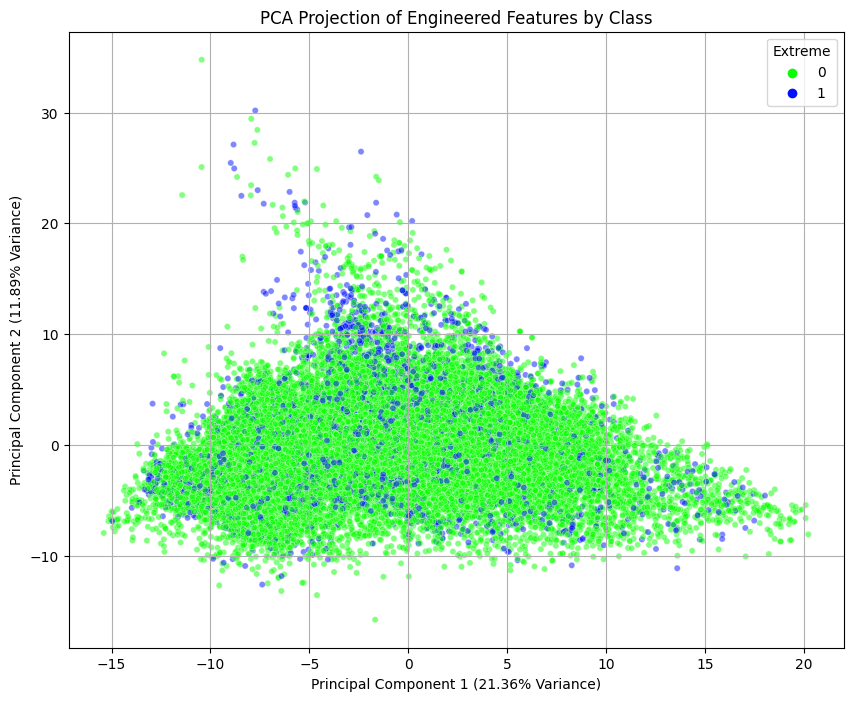

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Assuming X_eng and y_eng are your engineered features and labels ---
# It's crucial to scale data BEFORE applying PCA
scaler_viz = StandardScaler()
X_eng_scaled = scaler_viz.fit_transform(X_eng) # Use the full engineered dataset here

print("Applying PCA for visualization...")
pca = PCA(n_components=2) # Project to 2 dimensions
X_pca = pca.fit_transform(X_eng_scaled)

print(f"Explained variance by first 2 PCs: {pca.explained_variance_ratio_.sum():.3f}")

# Create a DataFrame for plotting
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Extreme'] = y_eng # Add the target variable

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Extreme',
    palette=sns.color_palette("hsv", 2), # Use distinct colors
    data=df_pca,
    legend="full",
    alpha=0.5, # Use transparency for overlap
    s=20 # Adjust point size
)
plt.title('PCA Projection of Engineered Features by Class')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} Variance)')
plt.grid(True)
plt.show()

# You can repeat this using:
# from sklearn.manifold import TSNE
# tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=300) # Adjust params
# X_tsne = tsne.fit_transform(X_eng_scaled)
# # ... then plot X_tsne

# Or using UMAP (install umap-learn: pip install umap-learn)
# import umap
# reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
# X_umap = reducer.fit_transform(X_eng_scaled)
# # ... then plot X_umap

In [27]:
%pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [28]:
# Core & Previous Imports
import pandas as pd
import numpy as np
import time
import warnings
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Dimensionality Reduction & Scaling
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    print("Warning: UMAP not found ('pip install umap-learn'). Using PCA for clustering input.")
    UMAP_AVAILABLE = False

# Clustering Algorithms
from sklearn.cluster import KMeans, DBSCAN
try:
    import hdbscan # Install: pip install hdbscan
    HDBSCAN_AVAILABLE = True
except ImportError:
    print("Warning: HDBSCAN not found ('pip install hdbscan'). Skipping HDBSCAN.")
    HDBSCAN_AVAILABLE = False

# Evaluation Metrics & Neighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

# --- Configuration ---
ENGINEERED_FEATURES_FILE = 'engineered_features_cache.pkl'
RANDOM_STATE = 42

# Dim Reduction
if UMAP_AVAILABLE:
    N_COMPONENTS_FOR_CLUSTERING = 5 # More robust clustering
    REDUCER_METHOD = "UMAP"
else:
    N_COMPONENTS_FOR_CLUSTERING = 10 # Need more variance if using PCA
    REDUCER_METHOD = "PCA"
N_COMPONENTS_FOR_VIZ = 2

# K-Means Settings
K_RANGE = range(2, 11) # Range of k values to test

# DBSCAN Settings (Initial guesses, tune after k-distance plot)
# Needs tuning based on k-distance plot
MIN_SAMPLES_DBSCAN = N_COMPONENTS_FOR_CLUSTERING * 2 # Heuristic: 2 * dimensions
EPS_DBSCAN = 0.5 # Placeholder, MUST be tuned

# HDBSCAN Settings
MIN_CLUSTER_SIZE_HDBSCAN = 50 # Min points to form a cluster (adjust based on data)
MIN_SAMPLES_HDBSCAN = None # Optional: min samples to be a core point (often left default)

# Set random seeds & suppress warnings
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

print(f"Configuration loaded. Clustering will use data reduced via {REDUCER_METHOD}.")

Configuration loaded. Clustering will use data reduced via UMAP.


In [19]:
# --- Load Engineered Features (assuming y_eng exists but we ignore it mostly) ---
X_eng, y_eng = None, None # Initialize
if os.path.exists(ENGINEERED_FEATURES_FILE):
    print(f"Loading cached features from {ENGINEERED_FEATURES_FILE}...")
    try:
        with open(ENGINEERED_FEATURES_FILE, 'rb') as f: X_eng, y_eng = pickle.load(f)
        print(f"Loaded successfully. X_eng shape: {X_eng.shape}")
        if not all(X_eng.dtypes.apply(pd.api.types.is_numeric_dtype)):
             print("Warning: Non-numeric types found. Coercing and filling NaNs...")
             X_eng = X_eng.apply(pd.to_numeric, errors='coerce').fillna(X_eng.median()).fillna(0)
    except Exception as e: print(f"Error loading cache: {e}")
else: print(f"Error: Cached features file not found: {ENGINEERED_FEATURES_FILE}")

# --- Scale Data ---
X_scaled = None
if X_eng is not None:
    print("\nScaling engineered features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_eng)
    print(f"Data scaled. Shape: {X_scaled.shape}")
else: print("Cannot proceed without engineered data.")

Loading cached features from engineered_features_cache.pkl...
Loaded successfully. X_eng shape: (35137, 141)

Scaling engineered features...
Data scaled. Shape: (35137, 141)


In [30]:
X_reduced_for_clustering = None
X_reduced_for_viz = None

if X_scaled is not None:
    # --- Reduce for Clustering Input (UMAP or PCA) ---
    print(f"\nApplying {REDUCER_METHOD} to reduce to {N_COMPONENTS_FOR_CLUSTERING} dimensions for clustering...")
    start_time = time.time()
    if REDUCER_METHOD == "UMAP":
        reducer_cluster = umap.UMAP( n_components=N_COMPONENTS_FOR_CLUSTERING, n_neighbors=15,
                                     min_dist=0.1, metric='euclidean', random_state=RANDOM_STATE, n_jobs=1 )
    else: # PCA
        reducer_cluster = PCA(n_components=N_COMPONENTS_FOR_CLUSTERING, random_state=RANDOM_STATE)
    X_reduced_for_clustering = reducer_cluster.fit_transform(X_scaled)
    print(f"{REDUCER_METHOD} finished in {time.time() - start_time:.2f}s. Shape: {X_reduced_for_clustering.shape}")
    if REDUCER_METHOD == "PCA": print(f" Variance explained: {reducer_cluster.explained_variance_ratio_.sum():.3f}")

    # --- Reduce for Visualization (PCA to 2D) ---
    print(f"\nApplying PCA to reduce to {N_COMPONENTS_FOR_VIZ} dimensions for visualization...")
    start_time = time.time()
    pca_viz = PCA(n_components=N_COMPONENTS_FOR_VIZ, random_state=RANDOM_STATE)
    X_reduced_for_viz = pca_viz.fit_transform(X_scaled)
    print(f"PCA (for viz) finished in {time.time() - start_time:.2f}s. Shape: {X_reduced_for_viz.shape}")
    print(f" Variance explained: {pca_viz.explained_variance_ratio_.sum():.3f}")
else: print("Skipping dimensionality reduction.")


Applying UMAP to reduce to 5 dimensions for clustering...
UMAP finished in 54.31s. Shape: (35137, 5)

Applying PCA to reduce to 2 dimensions for visualization...
PCA (for viz) finished in 0.15s. Shape: (35137, 2)
 Variance explained: 0.332



--- Finding Optimal K for K-Means ---
Testing k from 2 to 10...


Testing K values:   0%|          | 0/9 [00:00<?, ?it/s]

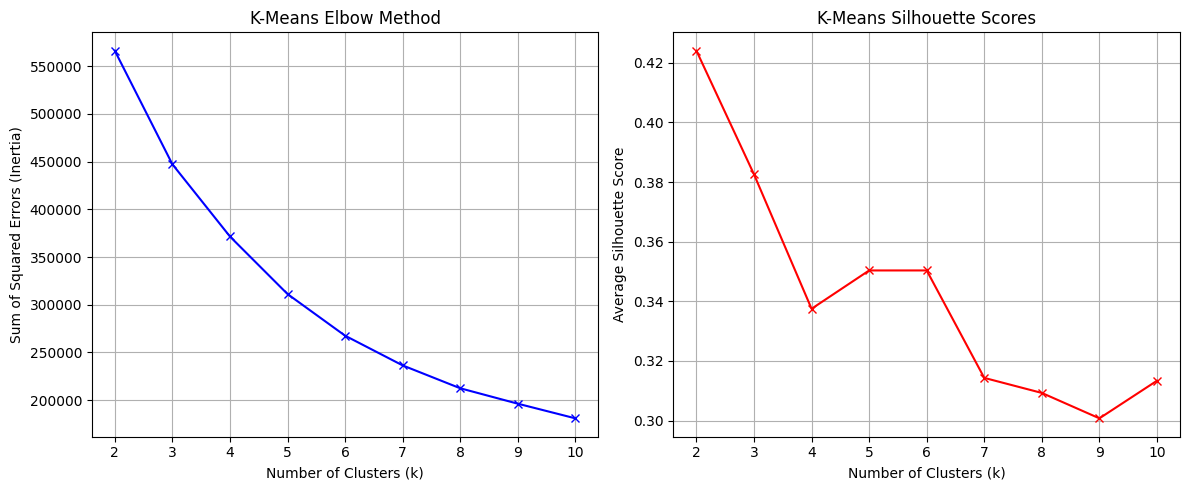


Optimal k based on peak Silhouette Score: 2
Examine the Elbow plot to potentially choose a different k.


In [31]:
if X_reduced_for_clustering is not None:
    print("\n--- Finding Optimal K for K-Means ---")
    sse = {} # Sum of Squared Errors (Inertia)
    silhouette_scores = {}

    k_range_list = list(K_RANGE)
    print(f"Testing k from {min(k_range_list)} to {max(k_range_list)}...")

    for k in tqdm(k_range_list, desc="Testing K values"):
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=RANDOM_STATE)
        kmeans.fit(X_reduced_for_clustering)
        sse[k] = kmeans.inertia_ # Sum of squared distances to closest centroid
        # Silhouette score requires at least 2 labels, check number of unique labels found
        labels_k = kmeans.labels_
        if len(set(labels_k)) > 1:
             silhouette_scores[k] = silhouette_score(X_reduced_for_clustering, labels_k)
        else:
             silhouette_scores[k] = -1 # Assign invalid score if only one cluster found

    # Plot Elbow Method
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(list(sse.keys()), list(sse.values()), 'bx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Sum of Squared Errors (Inertia)')
    plt.title('K-Means Elbow Method')
    plt.grid(True)

    # Plot Silhouette Scores
    valid_silhouette_k = [k for k, score in silhouette_scores.items() if score > -1]
    valid_silhouette_scores = [silhouette_scores[k] for k in valid_silhouette_k]
    plt.subplot(1, 2, 2)
    if valid_silhouette_k: # Only plot if we have valid scores
         plt.plot(valid_silhouette_k, valid_silhouette_scores, 'rx-')
         plt.xlabel('Number of Clusters (k)')
         plt.ylabel('Average Silhouette Score')
         plt.title('K-Means Silhouette Scores')
         plt.grid(True)
    else:
         plt.text(0.5, 0.5, "No valid Silhouette scores calculated", ha='center', va='center')


    plt.tight_layout()
    plt.show()

    # Determine optimal K (often subjective)
    # Look for the "elbow" point in the SSE plot
    # Look for the peak in the Silhouette plot
    optimal_k = -1
    if valid_silhouette_k:
         optimal_k = valid_silhouette_k[np.argmax(valid_silhouette_scores)]
         print(f"\nOptimal k based on peak Silhouette Score: {optimal_k}")
    else:
         print("\nCould not determine optimal k from Silhouette scores.")
    print("Examine the Elbow plot to potentially choose a different k.")
    # You might need to manually set optimal_k here based on plots if automatic selection isn't clear
    # optimal_k = 3 # Example manual override
else:
    print("Skipping K-Means optimal k determination.")
    optimal_k = N_CLUSTERS # Fallback to default if needed later

In [32]:
kmeans_labels = None
kmeans_model_final = None

if X_reduced_for_clustering is not None and optimal_k > 1:
    print(f"\n--- Running Final K-Means with k={optimal_k} ---")
    start_time = time.time()
    kmeans_model_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, max_iter=300, random_state=RANDOM_STATE)
    kmeans_labels = kmeans_model_final.fit_predict(X_reduced_for_clustering)
    print(f"K-Means finished in {time.time() - start_time:.2f} seconds.")
    print(f"Cluster distribution:\n{pd.Series(kmeans_labels).value_counts()}")

    # --- Evaluate K-Means ---
    print("\nK-Means Internal Evaluation:")
    try:
        s_score = silhouette_score(X_reduced_for_clustering, kmeans_labels)
        db_score = davies_bouldin_score(X_reduced_for_clustering, kmeans_labels)
        print(f"  Silhouette Score: {s_score:.4f}")
        print(f"  Davies-Bouldin Index: {db_score:.4f} (Lower is better)")
    except Exception as e:
        print(f"  Evaluation failed: {e}")

else:
    print("\nSkipping final K-Means run (optimal k not determined or <= 1).")


--- Running Final K-Means with k=2 ---
K-Means finished in 0.09 seconds.
Cluster distribution:
0    24051
1    11086
Name: count, dtype: int64

K-Means Internal Evaluation:
  Silhouette Score: 0.4240
  Davies-Bouldin Index: 0.9555 (Lower is better)



--- Tuning DBSCAN `eps` parameter using k-distance plot ---
Calculating distances for k = 10 nearest neighbors...


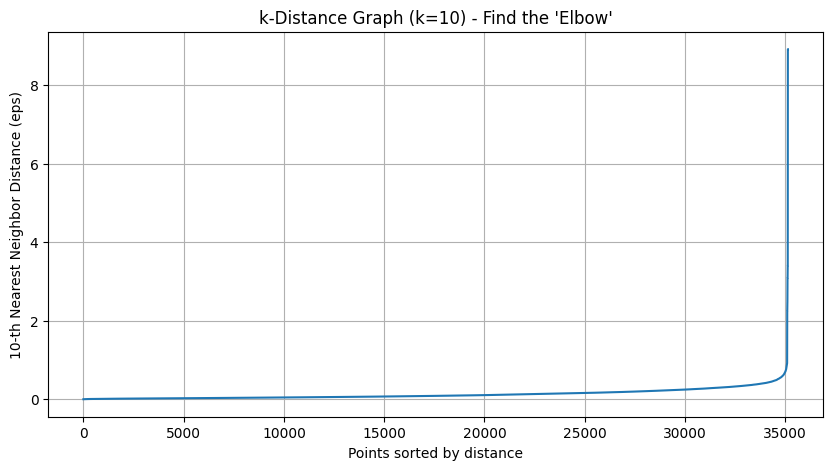


Look for the 'elbow' point in the plot above.
This indicates a suitable value for the `eps` parameter for DBSCAN.
Current placeholder eps = 0.5
You MUST manually update the 'EPS_DBSCAN' variable based on the elbow point.


In [33]:
if X_reduced_for_clustering is not None:
    print("\n--- Tuning DBSCAN `eps` parameter using k-distance plot ---")
    # Calculate distance to k-th nearest neighbor (k = MinPts)
    # MinPts heuristic: 2 * number_of_dimensions
    k_neighbors = MIN_SAMPLES_DBSCAN
    print(f"Calculating distances for k = {k_neighbors} nearest neighbors...")
    neighbors = NearestNeighbors(n_neighbors=k_neighbors)
    try:
        neighbors_fit = neighbors.fit(X_reduced_for_clustering)
        distances, indices = neighbors_fit.kneighbors(X_reduced_for_clustering)

        # Get the distance to the k-th neighbor (column index k_neighbors-1)
        k_distances = np.sort(distances[:, k_neighbors-1], axis=0)

        # Plot the k-distance graph
        plt.figure(figsize=(10, 5))
        plt.plot(k_distances)
        plt.xlabel("Points sorted by distance")
        plt.ylabel(f"{k_neighbors}-th Nearest Neighbor Distance (eps)")
        plt.title(f"k-Distance Graph (k={k_neighbors}) - Find the 'Elbow'")
        plt.grid(True)
        plt.show()

        print(f"\nLook for the 'elbow' point in the plot above.")
        print(f"This indicates a suitable value for the `eps` parameter for DBSCAN.")
        print(f"Current placeholder eps = {EPS_DBSCAN}")
        # --- !!! IMPORTANT: Manually set EPS_DBSCAN based on the plot !!! ---
        # eps_dbscan_tuned = 1.5 # Example: Replace with value from elbow
        # EPS_DBSCAN = eps_dbscan_tuned
        print("You MUST manually update the 'EPS_DBSCAN' variable based on the elbow point.")

    except Exception as e:
        print(f"Could not generate k-distance plot: {e}")

else:
    print("Skipping DBSCAN parameter tuning.")

In [34]:
dbscan_labels = None
dbscan_model = None

if X_reduced_for_clustering is not None:
     # Ensure EPS_DBSCAN has been potentially updated from the plot analysis
     print(f"\n--- Running DBSCAN with eps={EPS_DBSCAN:.4f} and min_samples={MIN_SAMPLES_DBSCAN} ---")
     start_time = time.time()
     dbscan_model = DBSCAN(eps=EPS_DBSCAN, min_samples=MIN_SAMPLES_DBSCAN, n_jobs=-1)
     dbscan_labels = dbscan_model.fit_predict(X_reduced_for_clustering)
     print(f"DBSCAN finished in {time.time() - start_time:.2f} seconds.")

     n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
     n_noise = list(dbscan_labels).count(-1)
     print(f"Estimated number of clusters (excl. noise): {n_clusters_db}")
     print(f"Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
     print(f"Cluster distribution (incl. noise -1):\n{pd.Series(dbscan_labels).value_counts()}")

     # --- Evaluate DBSCAN ---
     # Filter out noise points for evaluation metrics like Silhouette
     if n_clusters_db > 1 and n_noise < len(dbscan_labels):
          mask = dbscan_labels != -1
          X_eval = X_reduced_for_clustering[mask]
          labels_eval = dbscan_labels[mask]
          print("\nDBSCAN Internal Evaluation (on non-noise points):")
          try:
               s_score = silhouette_score(X_eval, labels_eval)
               db_score = davies_bouldin_score(X_eval, labels_eval)
               print(f"  Silhouette Score: {s_score:.4f}")
               print(f"  Davies-Bouldin Index: {db_score:.4f}")
          except Exception as e:
               print(f"  Evaluation failed: {e}")
     else:
          print("\nSkipping DBSCAN internal evaluation (too few clusters or only noise).")
else:
    print("\nSkipping DBSCAN run.")


--- Running DBSCAN with eps=0.5000 and min_samples=10 ---
DBSCAN finished in 0.50 seconds.
Estimated number of clusters (excl. noise): 155
Number of noise points: 238 (0.7%)
Cluster distribution (incl. noise -1):
3      21927
6       2890
17       821
38       587
42       560
       ...  
97        11
87        11
105       10
94        10
138       10
Name: count, Length: 156, dtype: int64

DBSCAN Internal Evaluation (on non-noise points):
  Silhouette Score: -0.2460
  Davies-Bouldin Index: 0.8842


In [35]:
hdbscan_labels = None
hdbscan_model = None

if HDBSCAN_AVAILABLE and X_reduced_for_clustering is not None:
    print(f"\n--- Running HDBSCAN with min_cluster_size={MIN_CLUSTER_SIZE_HDBSCAN} ---")
    start_time = time.time()
    try:
        hdbscan_model = hdbscan.HDBSCAN(
            min_cluster_size=MIN_CLUSTER_SIZE_HDBSCAN,
            min_samples=MIN_SAMPLES_HDBSCAN, # Often None (default) is fine
            # core_dist_n_jobs=-1 # Use all cores if available and safe
            # gen_min_span_tree=True # Needed for some plotting features
        )
        hdbscan_labels = hdbscan_model.fit_predict(X_reduced_for_clustering)
        print(f"HDBSCAN finished in {time.time() - start_time:.2f} seconds.")

        n_clusters_hdb = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
        n_noise_hdb = list(hdbscan_labels).count(-1)
        print(f"Estimated number of clusters (excl. noise): {n_clusters_hdb}")
        print(f"Number of noise points: {n_noise_hdb} ({n_noise_hdb/len(hdbscan_labels)*100:.1f}%)")
        print(f"Cluster distribution (incl. noise -1):\n{pd.Series(hdbscan_labels).value_counts()}")

        # --- Evaluate HDBSCAN ---
        if n_clusters_hdb > 1 and n_noise_hdb < len(hdbscan_labels):
             mask = hdbscan_labels != -1
             X_eval = X_reduced_for_clustering[mask]
             labels_eval = hdbscan_labels[mask]
             print("\nHDBSCAN Internal Evaluation (on non-noise points):")
             try:
                  s_score = silhouette_score(X_eval, labels_eval)
                  db_score = davies_bouldin_score(X_eval, labels_eval)
                  print(f"  Silhouette Score: {s_score:.4f}")
                  print(f"  Davies-Bouldin Index: {db_score:.4f}")
             except Exception as e:
                  print(f"  Evaluation failed: {e}")
        else:
             print("\nSkipping HDBSCAN internal evaluation (too few clusters or only noise).")

    except Exception as e:
        print(f"ERROR during HDBSCAN: {e}")
        hdbscan_labels = None # Ensure labels are None if it failed

elif not HDBSCAN_AVAILABLE:
    print("\nSkipping HDBSCAN run (library not installed).")
else:
    print("\nSkipping HDBSCAN run (no reduced data).")


--- Running HDBSCAN with min_cluster_size=50 ---
HDBSCAN finished in 2.90 seconds.
Estimated number of clusters (excl. noise): 140
Number of noise points: 13762 (39.2%)
Cluster distribution (incl. noise -1):
-1      13762
 94      2283
 138     1285
 0        821
 100      625
        ...  
 4         53
 66        52
 105       52
 41        52
 31        52
Name: count, Length: 141, dtype: int64

HDBSCAN Internal Evaluation (on non-noise points):
  Silhouette Score: 0.6043
  Davies-Bouldin Index: 0.4646



--- Visualizing Clustering Results (using 2D PCA projection) ---


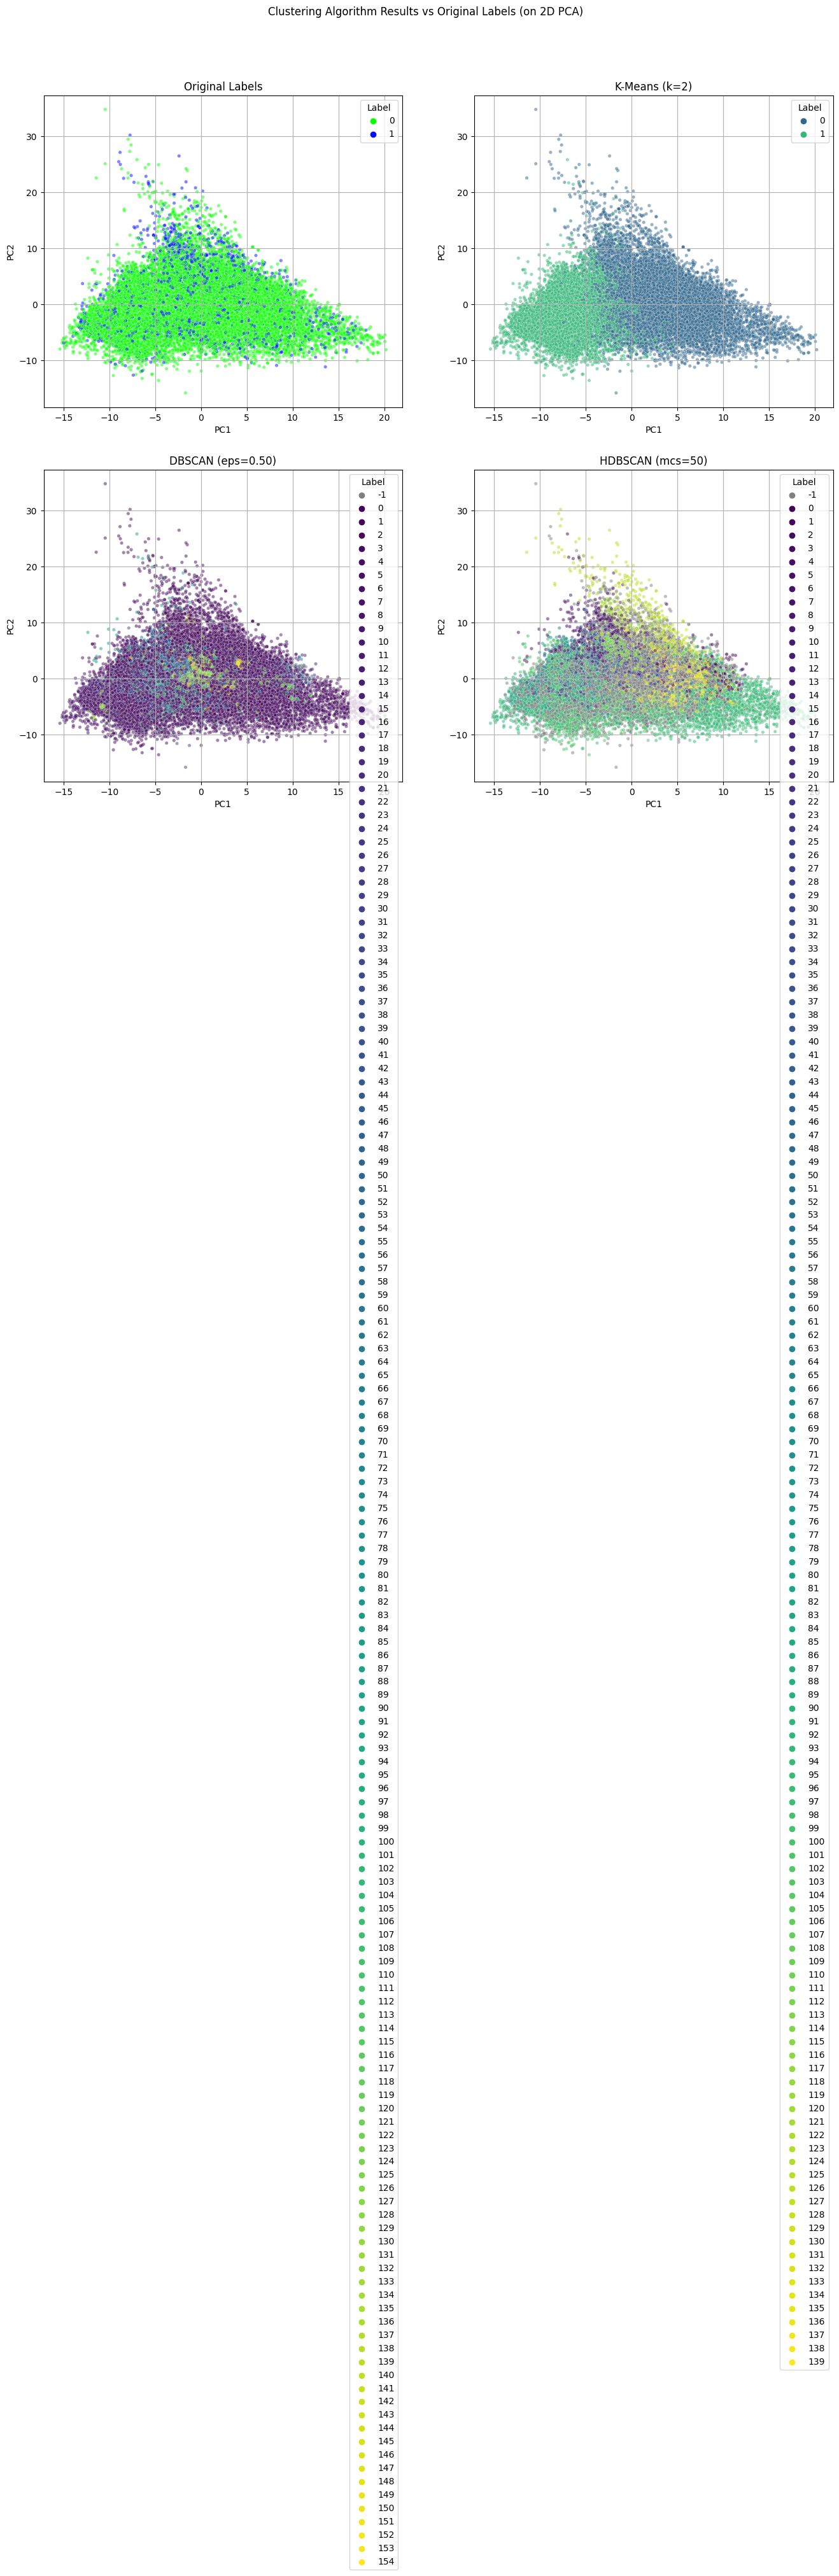


--- Unsupervised Clustering Experiment Finished ---


In [37]:
if X_reduced_for_viz is not None:
    print("\n--- Visualizing Clustering Results (using 2D PCA projection) ---")

    # Determine how many plots needed
    plot_labels = {'Original Labels': y_eng} # Always include original if available
    if kmeans_labels is not None: plot_labels[f'K-Means (k={optimal_k})'] = kmeans_labels
    if dbscan_labels is not None: plot_labels[f'DBSCAN (eps={EPS_DBSCAN:.2f})'] = dbscan_labels
    if hdbscan_labels is not None: plot_labels[f'HDBSCAN (mcs={MIN_CLUSTER_SIZE_HDBSCAN})'] = hdbscan_labels

    n_plots = len(plot_labels)
    if n_plots == 0:
        print("No clustering results or original labels available to visualize.")
    else:
        n_cols = 2
        n_rows = (n_plots + n_cols - 1) // n_cols # Calculate required rows
        fig_viz, axes_viz = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 7 * n_rows), squeeze=False) # Ensure axes is always 2D array
        axes_viz = axes_viz.flatten() # Flatten for easy iteration

        plot_idx = 0
        for title, labels in plot_labels.items():
            if labels is None: continue # Skip if labels are missing

            ax = axes_viz[plot_idx]
            df_viz = pd.DataFrame(X_reduced_for_viz, columns=['PC1', 'PC2'])
            df_viz['Label'] = labels

            # Use specific palette for original labels, different for clusters
            if title == 'Original Labels':
                palette = sns.color_palette("hsv", 2)
            else:
                n_unique_labels = len(set(labels))
                # Handle noise (-1) explicitly if present
                unique_clusters = sorted([l for l in set(labels) if l != -1])
                cluster_colors = sns.color_palette("viridis", len(unique_clusters))
                palette_map = {label: color for label, color in zip(unique_clusters, cluster_colors)}
                if -1 in set(labels):
                    palette_map[-1] = (0.5, 0.5, 0.5) # Assign grey to noise
                palette = palette_map

            sns.scatterplot(
                x='PC1', y='PC2', hue='Label', data=df_viz,
                palette=palette, legend="full", # Avoid overly large legends
                alpha=0.5, s=15, ax=ax
            )
            ax.set_title(title)
            ax.grid(True)
            plot_idx += 1

        # Hide any unused subplots
        for i in range(plot_idx, len(axes_viz)):
            fig_viz.delaxes(axes_viz[i])

        plt.suptitle("Clustering Algorithm Results vs Original Labels (on 2D PCA)")
        plt.tight_layout(rect=[0, 0.03, 1, 0.96])
        plt.show()

else:
    print("\nSkipping visualization.")

print("\n--- Unsupervised Clustering Experiment Finished ---")

## Testing only images data